In [1]:
import argparse
import os
import re

import torch.nn.functional as F

os.environ["TORCHINDUCTOR_DISABLE"] = "1"
os.environ["TORCH_COMPILE"] = "0"
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["DISABLE_TORCH_COMPILE"] = "1"
os.environ["TRANSFORMERS_NO_COMPILE"] = "1"
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from safetensors.torch import load_file as load_safetensors
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (adjusted_rand_score, balanced_accuracy_score,
                             calinski_harabasz_score, classification_report,
                             davies_bouldin_score, pairwise_distances,
                             silhouette_score)
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import umap
import glob
from scipy.stats import spearmanr


In [2]:
models = [ "google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]


output_dir = "/data/erblina/Master_thesis"

datasets_list = ["walledai/AdvBench","walledai/DTStereotype", "walledai/CatHarmfulQA","walledai/DTToxicity","truthfulqa/truthful_qa"]


model_steering_1 = {'Qwen/Qwen2.5-3B': {'layers': [ 'model.layers.19', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 1.6, 1.6, 1.6], 'alphas_down': [ -1.8, -2.0, -2.0], 'max_avg_tox': [0.87, 0.87, 0.795, 0.76], 'min_avg_tox': [0.21, 0.21, 0.22, 0.19]},
    'Qwen/Qwen2.5-3B-Instruct': {'layers': [ 'model.layers.21', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 2.0, 2.0, 2.0], 'alphas_down': [ -0.6, -0.6, -0.6], 'max_avg_tox': [0.79, 0.79, 0.785, 0.78], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B-Instruct': {'layers': [ 'model.layers.9', 'model.layers.7', 'model.layers.8'], 'alphas_up': [ 2.0, 1.8, 1.6], 'alphas_down': [ -0.8, -1.0, -0.8], 'max_avg_tox': [0.75, 0.75, 0.735, 0.715], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B': {'layers': ['model.layers.5', 'model.layers.7', 'model.layers.4'], 'alphas_up': [-0.15, -0.07, 0.05], 'alphas_down': [-2.0, -1.5, -2.0], 'max_avg_tox': [0.4, 0.39, 0.39], 'min_avg_tox': [0.09, 0.085, 0.09]},
    'google/gemma-2-2b-it': {'layers': [ 'model.layers.10', 'model.layers.11', 'model.layers.12'], 'alphas_up': [ 1.5, 1.1, 1.0], 'alphas_down': [-0.3, -0.25, -0.2], 'max_avg_tox': [0.63, 0.63, 0.615, 0.595], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'meta-llama/Llama-3.2-3B-Instruct': {'layers': [ 'model.layers.12', 'model.layers.13', 'model.layers.14'], 'alphas_up': [ 2.0, 1.6, 2.0], 'alphas_down': [ -0.8, -0.5, -0.5], 'max_avg_tox': [0.82, 0.82, 0.81, 0.79], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'google/gemma-2-2b': {'layers': [ 'model.layers.6', 'model.layers.7', 'model.layers.13'], 'alphas_up': [ 1.2, 1.3, 1.4], 'alphas_down': [ -2.0, -1.8, -1.8], 'max_avg_tox': [0.36, 0.36, 0.35, 0.36], 'min_avg_tox': [0.135, 0.02, 0.035, 0.065]},
    'meta-llama/Llama-3.2-3B': {'layers': [ 'model.layers.12', 'model.layers.10', 'model.layers.11'], 'alphas_up': [ 0.7, 1.0, 1.0], 'alphas_down': [ -2.0, -1.4, -1.6], 'max_avg_tox': [0.605, 0.57, 0.575, 0.6], 'min_avg_tox': [0.385, 0.3, 0.33, 0.36]},
        }

In [3]:
def load_harmbench(model, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    ###### HARMBENCH DATASET ######
    labels = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    hidden_states = load_safetensors(
        os.path.join(f"{output_dir}/{safe_model_name}", f"hidden_states_pure.safetensors"))
    
    side = 'toxic'
    # # Define path pattern
    # pattern = f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_*.npy"

    # # Find all matching files
    # files = sorted(glob.glob(pattern))

    # # Load them into a dictionary keyed by alpha
    # data = {}
    # for file in files:
    #     # Extract the alpha value from filename
    #     alpha_str = os.path.splitext(os.path.basename(file))[0].split('_alpha_')[-1]
    #     alpha = float(alpha_str)
    #     data[alpha] = np.load(file, allow_pickle=True).item()

    return hidden_states, labels #, data

def load_datasets(model, dataset, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
    hidden_states_data = load_safetensors(os.path.join(output_dir, safe_model_name, f"{safe_dataset}_hidden_states_pure.safetensors"))
    labels_data = np.load(f"{output_dir}/{safe_model_name}/labels_{safe_dataset}.npy")

    return hidden_states_data, labels_data

def load_steering_dataset(model, dataset, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after_dataset = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_dataset_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after_dataset,
            alpha_d : labels_after_dataset_d
        }

    return data

def load_steering_harmbench(model, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after,
            alpha_d : labels_after_d
        }

    return data

def load_harmbench_atten(model, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    ###### HARMBENCH DATASET ######
    attentions = load_safetensors(
        os.path.join(f"{output_dir}/{safe_model_name}", f"attention_states_pure.safetensors"))
    layer_names = sorted(list(attentions.keys()), key=lambda x: int(x.split('.')[2]))
    atten_flat = {}
    for key in layer_names:
        a = attentions[key].reshape(attentions[key].shape[0], -1)
        atten_flat[key] = a
        
    labels = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    return attentions, atten_flat, labels

def load_datasets_atten(model, dataset, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
    hidden_states_data = load_safetensors(os.path.join(output_dir, safe_model_name, f"{safe_dataset}_attention_states_pure.safetensors"))
    labels_data = np.load(f"{output_dir}/{safe_model_name}/labels_{safe_dataset}.npy")

    layer_names = sorted(list(hidden_states_data.keys()), key=lambda x: int(x.split('.')[2]))

    atten_flat = {}
    for key in layer_names:
        a = hidden_states_data[key].reshape(hidden_states_data[key].shape[0], -1)
        atten_flat[key] = a

        
    return hidden_states_data, atten_flat, labels_data

In [ ]:
from scipy.spatial.distance import jensenshannon
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d  # optional smoothing

def plot_metric_ribbon(res, layers, metric, dataset_names=None,
                       color="tab:grey", smooth=0, ci="sem",
                       show_individual=True, dataset_list = None):
    """
    res[layer][metric] = list of similarities per dataset (same order across layers)
    layers: list of layer keys (sorted)
    dataset_names: list of dataset names in the same order as the list in res[layer][metric]
    ci: "sem" for mean±1.96*SEM, "std" for mean±STD
    smooth: moving-average window (0/1 = no smoothing)
    show_individual: plot thin lines per dataset (gray) for context
    """
    # Build matrix: D x L (datasets × layers)
    sims = np.array([rs for rs in res]).T  # shape (D, L)

    # If NaNs exist, use nan-safe stats
    mean = np.nanmean(sims, axis=0)
    if ci == "sem":
        sem = np.nanstd(sims, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(sims), axis=0))
        lo, hi = mean - 1.96 * sem, mean + 1.96 * sem
    else:  # "std"
        std = np.nanstd(sims, axis=0, ddof=1)
        lo, hi = mean - std, mean + std

    # Optional smoothing for presentation
    if smooth and smooth > 1:
        mean = uniform_filter1d(mean, size=smooth, mode="nearest")
        lo   = uniform_filter1d(lo,   size=smooth, mode="nearest")
        hi   = uniform_filter1d(hi,   size=smooth, mode="nearest")

    # X-axis as numeric layer IDs if your keys are like "model.layers.12"
    try:
        layer_ids = [int(str(l).split('.')[-1]) for l in layers]
    except Exception:
        layer_ids = list(range(len(layers)))

    # if palette is None:
        # pick a set of distinguishable colors
    if dataset_list is not None:
        cmap = plt.get_cmap("tab10")
        palette = [cmap(i % 10) for i in range(len(dataset_list)+1)][1:]
    else:
        palette = ["black"] * sims.shape[0]
    # Individual dataset lines (gray)
    if show_individual:
        for d in range(sims.shape[0]):
            plt.plot(layer_ids, sims[d], color=palette[d], linewidth=0.8, alpha=0.7, label=dataset_list[d] if dataset_list else None)

    # Ribbon + mean
    plt.fill_between(layer_ids, lo, hi, color=color, alpha=0.25, linewidth=0)
    plt.plot(layer_ids, mean, color='black', linewidth=2.5, label=f"{metric} mean ± {ci.upper()}")

def pairwise_js_divergence(vectors, n_bins=50):
    """
    Computes mean JS divergence between feature distributions of vectors.
    vectors: [N, D]
    """
    N, D = vectors.shape
    js_vals = []
    for i in range(N):
        for j in range(i+1, N):
            # Make histograms of feature activations
            hist_i, bins = np.histogram(vectors[i].cpu(), bins=n_bins, density=True)
            hist_j, _    = np.histogram(vectors[j].cpu(), bins=bins, density=True)
            # Replace zeros to avoid NaN
            hist_i += 1e-8
            hist_j += 1e-8
            js = jensenshannon(hist_i, hist_j)
            js_vals.append(js)
    return js_vals, np.mean(js_vals), np.std(js_vals)

def get_correlation_matrices(steering_vec, random_vec):
    cos_sim = F.cosine_similarity(
        steering_vec.unsqueeze(1), steering_vec.unsqueeze(0), dim=-1
    )  # [N, N]

    # --- Correlation matrix ---
    # torch.corrcoef expects [D, N] shape, so transpose
    corr_mat = torch.corrcoef(steering_vec)  # [N, N]

    N = steering_vec.shape[0]
    mask = ~torch.eye(N, dtype=torch.bool, device=steering_vec.device)
    cos_s = cos_sim[mask].float().numpy()
    corr_s = corr_mat[mask].float().numpy()
    mean_cos = cos_sim[mask].mean().item()
    mean_corr = corr_mat[mask].mean().item()



    cos_with_random = F.cosine_similarity(steering_vec, random_vec.unsqueeze(0), dim=-1)  # [N]
    cos_r = cos_with_random.float().numpy() #float(cos_with_random.mean().item())

    # --- Pearson correlation vs random vector ---
    corr_with_random = []
    rv = random_vec - random_vec.mean()
    rv_std = rv.std()
    for i in range(steering_vec.shape[0]):
        sv = steering_vec[i] - steering_vec[i].mean()
        sv_std = sv.std()
        corr = (sv * rv).mean() / (sv_std * rv_std)
        corr_with_random.append(corr.item())
    corr_r = corr_with_random

    return  cos_s, cos_r, corr_s, corr_r



def single_js_divergence(target, vectors, n_bins=80):
    """
    Computes mean JS divergence between feature distributions of vectors.
    vectors: [N, D]
    """
    N, D = vectors.shape
    js_vals = []
    hist_t, bins = np.histogram(target.float().numpy(), bins=n_bins, density=True)
    hist_t += 1e-8
    hist_t = hist_t / hist_t.sum()


    for i in range(N):
        hist_i, bins = np.histogram(vectors[i].float().numpy(), bins=n_bins, density=True)
        # Replace zeros to avoid NaN
        hist_i += 1e-8
        hist_i = hist_i / hist_i.sum()
        js = jensenshannon(hist_t, hist_i)
        js_vals.append(js)

    return js_vals, np.mean(js_vals), np.std(js_vals)

def single_correlation_matrices(steering_vec, target, random_vec):
    
    cos_sim = F.cosine_similarity(steering_vec, target.unsqueeze(0), dim=-1)
    cos_s = cos_sim.float().numpy()

    new_vec = torch.cat([target.unsqueeze(0), steering_vec], dim=0)
    corr_mat = torch.corrcoef(new_vec)[0][1:]  # [N-1]
    corr_s = corr_mat.float().numpy()

    cos_with_random = F.cosine_similarity(steering_vec, random_vec.unsqueeze(0), dim=-1)  # [N]
    cos_r = cos_with_random.float().numpy() #float(cos_with_random.mean().item())

    new_vec_r = torch.cat([random_vec.unsqueeze(0), steering_vec], dim=0)
    corr_mat_r = torch.corrcoef(new_vec_r)[0][1:]  # [N-1]
    corr_r = corr_mat_r.float().numpy()

    return  cos_s, cos_r, corr_s, corr_r

models = [( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
           ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]
for pair in models:
    
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))#[5::10]
    yb = (v1b > 0).astype(int)
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    yi = (v1i > 0).astype(int)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))

    X_datab = []
    y_datab = []
    X_datai = []
    y_datai = []

    steering_vec_b = {}
    steering_vec_i = {}

    for data in datasets_list:
        X_d_b, y_d_b = load_datasets(model_base, data, output_dir)
        X_datab.append(X_d_b)
        y_datab.append(y_d_b)

        X_d_i, y_d_i = load_datasets(model_it, data, output_dir)
        X_datai.append(X_d_i)
        y_datai.append(y_d_i)

        print(data, X_d_b['model.layers.0'][y_d_b == 1].shape, X_d_b['model.layers.0'][y_d_b == 0].shape)
        print(data, X_d_i['model.layers.0'][y_d_i == 1].shape, X_d_i['model.layers.0'][y_d_i == 0].shape)



    side = 'toxic'
    js_vals_b = []
    cos_vals_b = []
    corr_vals_b = []
    js_vals_i = []
    cos_vals_i = []
    corr_vals_i = []
    corr_rval_i = []
    corr_rval_b = []
    cos_rval_b = []
    cos_rval_i = []
    for i, layer in enumerate(layer_names):
        steering_vec_b[layer] = []
        steering_vec_i[layer] = []


        # steering_vec_b[layer].append(steering_vector_a[layer][side].float())
        # steering_vec_i[layer].append(steering_vector_b[layer][side].float())


        for data, y  in zip(X_datab, y_datab):
            X = data[layer].float()
            vec = X[y==1].mean(dim=0) - X[y==0].mean(dim=0)
            steering_vec_b[layer].append(vec.float())

        for data, y  in zip(X_datai, y_datai):
            X = data[layer].float()
            vec = X[y==1].mean(dim=0) - X[y==0].mean(dim=0)
            steering_vec_i[layer].append(vec.float())

        # 🔹 Add one random vector to each stack (same dimension)
        dim = steering_vec_b[layer][0].shape[0]
        rand_vec_b = torch.randn(dim)
        rand_vec_i = torch.randn(dim)
        rand_vec_b = F.normalize(rand_vec_b, dim=-1)
        rand_vec_i = F.normalize(rand_vec_i, dim=-1)

        # steering_vec_b[layer].append(rand_vec_b)
        # steering_vec_i[layer].append(rand_vec_i)
        steering_b = steering_vector_a[layer][side].float()
        steering_i = steering_vector_b[layer][side].float()


        steering_vec_i[layer] = torch.stack(steering_vec_i[layer])
        steering_vec_b[layer] = torch.stack(steering_vec_b[layer])
        steering_vec_b[layer] = F.normalize(steering_vec_b[layer], dim=1)
        steering_vec_i[layer] = F.normalize(steering_vec_i[layer], dim=1)

        # cos_s_b, cos_r_b, corr_s_b, corr_r_b = single_correlation_matrices(steering_vec_b[layer], rand_vec_b)
        # cos_s_i, cos_r_i, corr_s_i, corr_r_i = get_correlation_matrices(steering_vec_i[layer], rand_vec_i)

        # js_b, js_v_b, js_std_b = pairwise_js_divergence(steering_vec_b[layer])
        # js_i, js_v_i, js_std_i = pairwise_js_divergence(steering_vec_i[layer])

        cos_s_b, cos_r_b, corr_s_b, corr_r_b = single_correlation_matrices(steering_vec_b[layer], steering_b, rand_vec_b)
        cos_s_i, cos_r_i, corr_s_i, corr_r_i = single_correlation_matrices(steering_vec_i[layer], steering_i, rand_vec_i)

        # js_b, js_v_b, js_std_b = single_js_divergence(steering_b, steering_vec_b[layer])
        # js_i, js_v_i, js_std_i = single_js_divergence(steering_i, steering_vec_i[layer])


        # js_vals_b.append(js_b)

        cos_vals_b.append(cos_s_b)
        corr_vals_b.append(corr_s_b)

        # js_vals_i.append(js_i)

        cos_vals_i.append(cos_s_i)
        corr_vals_i.append(corr_s_i)   

        corr_rval_b.append(float(torch.tensor(corr_r_b).mean().item()))
        corr_rval_i.append(float(torch.tensor(corr_r_i).mean().item()))
        cos_rval_b.append(float(torch.tensor(cos_r_b).mean().item()))
        cos_rval_i.append(float(torch.tensor(cos_r_i).mean().item()))



    fig, ax = plt.subplots(2,2, figsize=(8, 6), sharey='row')
    for row in ax:
        for axes in row:
            axes.tick_params(labelleft=True)
    dataset = [data.split('/')[-1] for data in datasets_list]
    pair_m = [model_base.split('/')[-1], model_it.split('/')[-1]]
    
    # for i, m in enumerate([js_vals_b, js_vals_i]): #, 'frobenius']):
    #     plt.subplot(3, 2, i+1)
    #     plt.histogram(m, bins=30, color='grey', alpha=0.7, edgecolor='black')
    #     # plot_metric_ribbon(m, layer_names, metric='JS', color="grey", #["tab:blue","tab:orange","tab:green","tab:purple","tab:red"][i],
    #     #                 smooth=2, ci="sem", show_individual=True, dataset_list=dataset)
    #     plt.xlabel("Layer")
    #     plt.ylabel("JS divergence")
    #     plt.title(f"{pair_m[i]}\n JS divergence")
    #     plt.grid(alpha=0.3)
        # plt.legend(loc="lower right")
    
    cos_r = [cos_rval_b, cos_rval_i]
    for i, m in enumerate([cos_vals_b, cos_vals_i]): #, 'frobenius']):
        j = i 
        # plt.subplot(2, 2, j+1)
        axes = ax[0, i]
        plt.sca(axes)
        plot_metric_ribbon(m, layer_names, metric='Cosine Similarity', color="grey", #["tab:blue","tab:orange","tab:green","tab:purple","tab:red"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=dataset)
        axes.plot(range(len(layer_names)), cos_r[i], color='black', linewidth=1, linestyle='--', label=f"Random")
        axes.set_xlabel("Layer")
        axes.set_ylabel("Cosine similarity")
        axes.set_title(f"{pair_m[i]}\n Cosine similarity")
        axes.grid(alpha=0.3)

        
    corr_r = [corr_rval_b, corr_rval_i]
    
    for i, m in enumerate([corr_vals_b, corr_vals_i]): #, 'frobenius']):
        j = i + 2
        # plt.subplot(2, 2, j+1)
        axes = ax[1, i]
        plt.sca(axes)

        plot_metric_ribbon(m, layer_names, metric='Pearson correlation', color="grey", #["tab:blue","tab:orange","tab:green","tab:purple","tab:red"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=dataset)
        axes.plot(range(len(layer_names)), corr_r[i], color='black', linewidth=1, linestyle='--', label=f"Random")
        axes.set_xlabel("Layer")
        axes.set_ylabel("Pearson correlation")
        axes.set_title(f"Pearson correlation")
        axes.grid(alpha=0.3)
        


    handles, labels = plt.gca().get_legend_handles_labels()
    handles = [handles[-1]] + handles[:-2]
    labels = [labels[-1]] + labels[:-2]
    plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')

    # plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.suptitle(f'RSA Similarity {model}')
    plt.suptitle('Similarity of SV (HarmBench) to SV (Datasets)')

    plt.tight_layout()
    safe_model_name_1 = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_model_name_2 = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    safe_model_name = f"{safe_model_name_1}_vs_{safe_model_name_2}"
    # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_steering_vectors_similarity.png", dpi=300, bbox_inches='tight')
    # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_steering_vectors_similarity.svg", dpi=300, bbox_inches='tight')

    plt.show()
    plt.close()





    




        

In [ ]:
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np
from scipy.spatial.distance import cdist, pdist, squareform

from scipy.spatial.distance import cdist, pdist, squareform
import numpy as np
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def kde_panel_single(fig, grid_pos, x, y, title="", xlabel="", ylabel="",
                     color="steelblue", levels=10, fill=False, bw=None):
    """
    2D KDE + top/right 1D KDE marginals for a single dataset (no classes).
    grid_pos: (row, col) index in an outer gridspec of shape (1,2) or (2,2).
    """
    outer = fig.add_gridspec(1, 2)  # change to (2,2) if you want a 2x2 outer grid
    gs = outer[grid_pos[0], grid_pos[1]].subgridspec(4, 4, wspace=0.05, hspace=0.05)

    ax_joint = fig.add_subplot(gs[1:, :-1])
    ax_marg_x = fig.add_subplot(gs[0, :-1], sharex=ax_joint)
    ax_marg_y = fig.add_subplot(gs[1:, -1], sharey=ax_joint)

    # 2D KDE
    sns.kdeplot(x=x, y=y, ax=ax_joint, color=color, levels=levels,
                fill=fill, bw_method=bw, linewidths=1)

    # Optional reference & annotation
    lim = [
        np.nanmin([ax_joint.get_xlim()[0], ax_joint.get_ylim()[0]]),
        np.nanmax([ax_joint.get_xlim()[1], ax_joint.get_ylim()[1]])
    ]
    ax_joint.plot(lim, lim, ls='--', lw=1, color='gray', alpha=0.6)  # y=x line
    ax_joint.set_xlim(lim); ax_joint.set_ylim(lim)
    r = np.corrcoef(x, y)[0, 1]
    ax_joint.text(0.02, 0.98, f"r = {r:.2f}", ha='left', va='top',
                  transform=ax_joint.transAxes, fontsize=9)

    # 1D marginals
    sns.kdeplot(x=x, ax=ax_marg_x, color=color, fill=fill, alpha=0.4, linewidth=1, bw_method=bw)
    sns.kdeplot(y=y, ax=ax_marg_y, color=color, fill=fill, alpha=0.4, linewidth=1, bw_method=bw)

    # Clean up marginal axes
    ax_marg_x.set_axis_off()
    ax_marg_y.set_axis_off()
    ax_marg_x.set_title(title, fontsize=10, pad=8)

    ax_joint.set_xlabel(xlabel)
    ax_joint.set_ylabel(ylabel)

    return ax_joint

def inter_intra_distances(X, y):
    """
    Compute average intra-class and inter-class distances for each sample,
    suitable for scatter plotting.
    Returns:
        inter_means, intra_means : arrays of shape (n_samples,)
    """
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    n = X.shape[0]

    # Full distance matrix (n x n)
    D = squareform(pdist(X, metric='cosine'))

    inter_means = np.zeros(n)
    intra_means = np.zeros(n)

    for i in range(n):
        same = (y == y[i])
        diff = ~same

        same[i] = False  # exclude self
        intra_vals = D[i, same]
        inter_vals = D[i, diff]

        intra_means[i] = intra_vals.mean() if np.any(same) else np.nan
        inter_means[i] = inter_vals.mean() if np.any(diff) else np.nan

    # Drop NaNs (e.g. if only one sample of a class)
    valid = ~np.isnan(intra_means) & ~np.isnan(inter_means)
    return inter_means[valid], intra_means[valid]


models = [#( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
          ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]


for pair in models:
    
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))
    yb = (v1b > 0).astype(int)
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    yi = (v1i > 0).astype(int)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))

    X_datab = []
    y_datab = []
    X_datai = []
    y_datai = []
    
    for data in datasets_list:
        X_d_b, y_d_b = load_datasets(model_base, data, output_dir)
        y_d_b = (y_d_b > 0).astype(int)
        X_datab.append(X_d_b)
        y_datab.append(y_d_b)

        X_d_i, y_d_i = load_datasets(model_it, data, output_dir)
        y_d_i = (y_d_i > 0).astype(int)
        X_datai.append(X_d_i)
        y_datai.append(y_d_i)


    t = 'toxic'
    res_base = {}
    res_it = {}
    layer_names = [layer for layer in layer_names if int(layer.split('.')[-1]) in [5, 19, 21, 10, 12, 6]]
    print(layer_names)
    for i, layer in enumerate(layer_names):
        # res_base[layer] = {}
        # res_it[layer] = {}
        # X_allb = []
        # y_allb = []
        # X_alli = []
        # y_alli = []
        inter_b = []
        intra_b = []
        inter_i = []
        intra_i = []
        y_b = []
        y_i = []

        i1, i2 = inter_intra_distances(X_1b[layer].float().numpy(), yb)
        inter_b.extend(i1)
        intra_b.extend(i2)
        y_b.extend(yb.tolist())
        i1, i2 = inter_intra_distances(X_1i[layer].float().numpy(), yi)
        inter_i.extend(i1)
        intra_i.extend(i2)
        y_i.extend(yi.tolist())

        

        for i, data in enumerate(X_datab):
            i1, i2 = inter_intra_distances(data[layer].float().numpy(), y_datab[i])
            inter_b.extend(i1)
            intra_b.extend(i2)
            y_b.extend(y_datab[i].tolist())

        for i, data in enumerate(X_datai):
            i1, i2 = inter_intra_distances(data[layer].float().numpy(), y_datai[i])
            inter_i.extend(i1)
            intra_i.extend(i2)
            if sum(y_datai[i] == 1) > 1:
                y_i.extend(y_datai[i].tolist())
            else:
                y_di = y_datai[i][y_datai[i]==0]
                y_i.extend(y_di.tolist())

           
        # fig = plt.figure(figsize=(8,4))

        # kde_panel_single(fig, (0,0),
        #                 inter_b, intra_b,
        #                 title=f"{model_base.split('/')[-1]}",
        #                 xlabel="Inter- distances", ylabel="Intra- distances",
        #                 color="royalblue", fill=False, levels=12)

        # kde_panel_single(fig, (0,1),
        #                 inter_i, intra_i,
        #                 title=f"{model_it.split('/')[-1]}",
        #                 xlabel="Inter- distances",
        #                 color="royalblue", fill=False, levels=12)

        # plt.suptitle(layer)
        # plt.tight_layout()
        # plt.show()
        # xy = np.vstack([inter_b, intra_b])
        # density = gaussian_kde(xy)(xy)
        
        fig, axes = plt.subplots(1, 2, figsize=(5, 3), sharex=True, sharey=True)
        inter_b = np.array(inter_b)
        intra_b = np.array(intra_b)
        inter_i = np.array(inter_i)
        intra_i = np.array(intra_i)
        y_b = np.array(y_b)
        y_i = np.array(y_i)

        print(len(inter_b), len(intra_b), len(y_b))
        
        axes[0].scatter(inter_b[y_b==0], intra_b[y_b==0], alpha=0.1, s=3, color='green', label='non-toxic')
        axes[0].scatter(inter_b[y_b==1], intra_b[y_b==1], alpha=0.1, s=3, color='red', label='toxic')

        axes[0].set_title(f"{model_base.split('/')[-1]}")
        axes[0].set_xlabel("Inter- distances")
        axes[0].set_ylabel("Intra- distances")

        axes[1].scatter(inter_i[y_i==0], intra_i[y_i==0], alpha=0.1, s=3, color='green', label='non-toxic')
        axes[1].scatter(inter_i[y_i==1], intra_i[y_i==1], alpha=0.1, s=3, color='red', label='toxic')

        axes[1].set_title(f"{model_it.split('/')[-1]}")
        axes[1].set_xlabel("Inter- distances")

        plt.suptitle(f"{layer}")
        plt.tight_layout()
        plt.show()

        # out = f"/home/fe/purelku/Desktop/Master_thesis/distance_panels/{safe_base}_vs_{safe_it}_{layer}.png"
        # os.makedirs(os.path.dirname(out), exist_ok=True)
        # plt.savefig(out, dpi=300, bbox_inches='tight')
        plt.close()



In [ ]:
models = [ "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "google/gemma-2-2b-it",
          "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]


for model_name in models:
    output_dir = "/data/erblina/Master_thesis"
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model_name)
    save_path = os.path.join(output_dir, safe_model_name)
   
    atten_tensors = load_safetensors(
        os.path.join(save_path, f"attention_states_pure.safetensors")
    )
    
    labels_before = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    layer_heads = {}
    all_head_data = []
    # if tox_dir not in ['pca', 'mean_head', 'diff']:
    #     tox_dir = 'mean'
    print(list(atten_tensors.keys()))
    layer_names = sorted(list(atten_tensors.keys()), key=lambda x: int(x.split('.')[2]))
    data_norm = []
    data_cos = []
    data_3 = []
    for layer_name in layer_names:
        if layer_name not in layer_heads:
            layer_heads[layer_name] = {}

        overall_mean = atten_tensors[layer_name].float().mean(dim=0)
        toxic_behaviour = atten_tensors[layer_name][labels_before==1].float().mean(dim=0)  # (num_heads, head_dim)
        non_toxic_behaviour = atten_tensors[layer_name][labels_before==0].float().mean(dim=0)  # (num_heads, head_dim)
        head_diff = toxic_behaviour - non_toxic_behaviour  # (num_heads, head_dim)

        sign = toxic_behaviour.norm(dim=-1) - non_toxic_behaviour.norm(dim=-1)
        # sign = toxic_behaviour.amax(dim=-1) - non_toxic_behaviour.amax(dim=-1)
        sign_ = torch.sign(sign)
        signed_scores_2 = 1 - F.cosine_similarity(toxic_behaviour, non_toxic_behaviour, dim=-1)  # non_toxic_behaviour, dim=-1) #[num_heads]
        signed_scores2 = signed_scores_2 * sign_
        data_norm.append(signed_scores2.float().numpy())


        
        r = toxic_behaviour.amax(0) - non_toxic_behaviour.amax(0)      # reference direction
        # r = toxic_behaviour - non_toxic_behaviour
        sims = F.cosine_similarity(atten_tensors[layer_name].float(), r.unsqueeze(0), dim=-1)
        signed_scores1 = sims.mean(0) 

        # signed_scores = signed_scores * sign_
        data_cos.append(signed_scores1.float().numpy())
        print(signed_scores1.shape, signed_scores_2.shape, sign_.shape)

        
        
        
        # print(d_3.shape)
        r = toxic_behaviour.mean(0) - non_toxic_behaviour.mean(0)      # reference direction
        sims = F.cosine_similarity(atten_tensors[layer_name].float(), r.unsqueeze(0), dim=-1)
        ar_max = torch.argmax(abs(sims), dim=0)
        signed_scores = sims[ar_max] #.mean(0)
        sign = torch.sign(signed_scores1)
        print(sign.shape)
        sign2 = (sign == sign_) * sign

        d_3 = signed_scores #* sign2
        # data_3.append(d_3.float().numpy())

        u = F.normalize(toxic_behaviour.amax(0) - non_toxic_behaviour.amax(0), dim=0)   # [D]

        sign = torch.sign(((toxic_behaviour - non_toxic_behaviour) @ u))  # [H]
        # Distance to overall mean as magnitude:
        mag  = overall_mean @ u.T #F.cosine_similarity(u, overall_mean, dim=-1)        # [H]
        signed_scores = mag #* sign                # [H]
        # data_3.append(signed_scores.float().numpy())
        # sign = toxic_behaviour.norm(dim=-1) - non_toxic_behaviour.norm(dim=-1)
        # # sign = toxic_behaviour.amax(dim=-1) - non_toxic_behaviour.amax(dim=-1)
        # sign_ = torch.sign(sign)
        # signed_scores_2 = 1 - F.cosine_similarity(toxic_behaviour, non_toxic_behaviour, dim=-1)  # non_toxic_behaviour, dim=-1) #[num_heads]
        # signed_scores2 = signed_scores_2 * sign_
        # data_norm.append(signed_scores2.float().numpy())
        # data_3.append(signed_scores2.float().numpy())
        # data_cos.append(signed_scores.float().numpy())
        u = (toxic_behaviour - non_toxic_behaviour).norm(dim=0)   # [head_dim]
        u = F.normalize(u, dim=0)                                 # unit vector

        # ---- 2. Per-head difference
        head_diffs = toxic_behaviour - non_toxic_behaviour         # [num_heads, head_dim]

        # ---- 3. Sign: whether each head’s difference aligns with the global direction
        sign_h = torch.sign(torch.matmul(head_diffs, u))           # [num_heads]

        # ---- 4. Magnitude: cosine distance between toxic and non-toxic means per head
        mag_h = 1 - F.cosine_similarity(toxic_behaviour, non_toxic_behaviour, dim=-1)  # [num_heads]

        # ---- 5. Final signed score
        score_h = sign_h * mag_h   

        data_3.append(score_h.float().numpy())
        
        

    data_norm = np.array(data_norm)  # (num_layers, num_heads)
    data_cos = np.array(data_cos)    # (num_layers, num_heads)
    data_3 = np.array(data_3)
    print(data_3.shape, data_cos.shape, data_norm.shape)
    data_norm_i = np.argsort(data_norm, axis=1)[:, ::-1]
    data_cos_i  = np.argsort(data_cos, axis=1)[:, ::-1]
    data_cos = np.take_along_axis(data_cos, data_norm_i, axis=1)
    data_norm = np.take_along_axis(data_norm, data_norm_i, axis=1)
    data_3 = np.take_along_axis(data_3, data_norm_i, axis=1)

    plt.figure(figsize=(8,3))
    plt.subplot(1,3,1)
    sns.heatmap(data_norm, cmap='bwr', center=0, cbar_kws={'label': 'Cosine Sim'})
    plt.title(f"Similarities-cos")
    plt.xlabel("Head (sorted)")
    plt.ylabel("Layer Index")
    plt.yticks(rotation=0)
    plt.xticks([])
    plt.subplot(1,3,2)
    sns.heatmap(data_3, cmap='bwr', center=0, cbar_kws={'label': 'Cosine Sim'})
    plt.title(f"Similarities - proj_sv")
    plt.xlabel("Head (sorted)")
    plt.ylabel("Layer Index")   
    plt.yticks(rotation=0)
    plt.xticks([])
    plt.subplot(1,3,3)
    sns.heatmap(data_cos, cmap='bwr', center=0, cbar_kws={'label': 'Cosine Sim'})
    plt.title(f"Similarities-cos_sv")
    plt.xlabel("Head (sorted)")
    plt.ylabel("Layer Index")
    plt.yticks(rotation=0)
    plt.xticks([])
    plt.suptitle(f"{model_name}")
    plt.tight_layout()
    plt.show()



In [ ]:
def upper_triangle(mat):
    """Flatten the upper triangle (excluding diagonal) of a symmetric matrix."""
    if mat.size == 0:
        return np.array([])
    i, j = np.triu_indices_from(mat, k=1)
    return mat[i, j]

models = ["meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]

for model in models: 
    layers = model_steering_1[model]['layers']
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    # plt.figure(figsize=(12,8))
    for i, layer in enumerate(layers):
        
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        v1 = (v1 > 0).astype(int)
       
        X_1[layer] = F.normalize(X_1[layer], p=2, dim=1)
        print(sum(v1==1), sum(v1==0))
        X.append(X_1[layer].float().numpy())
        


        y.append(v1)
        print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)
            X.append(X_2[layer].float().numpy())
            y.append(v2)
            print(sum(v2==1), sum(v2==0))
            print(f"  Dataset: {data}, Hidden states shape: {X_2[layer].shape}, Labels shape: {v2.shape}")
           
            X_2[layer] = F.normalize(X_2[layer], p=2, dim=1)
            


        X_all = np.concatenate(X, axis=0)
        X_c = cosine_similarity(X_all)
        y_all = np.concatenate(y, axis=0)
        toxmask = (y_all==1)
        nontoxmask = (y_all==0)
        tox_block = X_c[toxmask][:, toxmask]
        nontox_block = X_c[nontoxmask][:, nontoxmask]
        between_block = X_c[toxmask][:, nontoxmask]
        cos_tox = upper_triangle(tox_block)
        cos_nontox = upper_triangle(nontox_block)
        cos_between = between_block.ravel()
        # cos_tox = X_c[y_all==1][:, y_all==1]
        # cos_nontox = X_c[y_all==0][:, y_all==0]
        # cos_between = X_c[y_all==1][:, y_all==0]

        data = [
            np.array(cos_tox).flatten(),
            np.array(cos_nontox).flatten(),
            np.array(cos_between).flatten()
            ]
        labels = ["Toxic", "Non-Toxic", "Between Classes"]
        colors = ["tab:red", "tab:green", "tab:blue"]  # consistent colors
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        bp = plt.boxplot(
            data,
            labels=labels,
            patch_artist=True,  # allows coloring boxes
            widths=0.3,
            showfliers=False,   # hide the black dots (outliers)
        )

        # Apply custom colors
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            # patch.set_alpha(1)  # optional transparency

        # Optional: adjust median, whisker, and cap colors for readability
        for median in bp['medians']:
            median.set(color='black', linewidth=1.2)
        for whisker in bp['whiskers']:
            whisker.set(color='black', linewidth=1)
        for cap in bp['caps']:
            cap.set(color='black', linewidth=1)
        for mean in bp['means']:
            mean.set(color='black', marker='D', markeredgecolor='black')

        
        
        
        
        plt.title(f"{model}, {layer}")
        plt.ylabel("Cosine Similarity")

        plt.subplot(1, 2, 2)
        sns.kdeplot(np.array(cos_between).flatten(), color='tab:blue', fill=True, alpha=0.3)
        sns.kdeplot(np.array(cos_tox).flatten(), color='tab:red', fill=True, alpha=0.3)
        sns.kdeplot(np.array(cos_nontox).flatten(), color='tab:green', fill=True, alpha=0.3)

        plt.ylabel("Density")
        plt.xlabel("Cosine Similarity")
        plt.legend(["Between Classes", "Toxic", "Non-Toxic"])
        # plt.ylim(0.7, 1.0)  # adjust based on your range
        plt.tight_layout()
        # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_cos_similarity_{layer}.png", dpi=300, bbox_inches='tight')
        # plt.show()
        plt.close()
    


In [ ]:
def upper_triangle(matrix):
    i, j = np.triu_indices_from(matrix, k=1)
    return matrix[i, j]


def rsa_similarity(model_rdm, true_rdm, method='spearman'):
    # vectorize upper triangles
    if model_rdm.ndim == 2:
        m = upper_triangle(model_rdm)
        t = upper_triangle(true_rdm)
    else:
        m = model_rdm
        t = true_rdm

    if method == 'spearman':
        corr, _ = spearmanr(m, t)
    elif method == 'pearson':
        from scipy.stats import pearsonr
        corr, _ = pearsonr(m, t)
    elif method == 'kendall':
        from scipy.stats import kendalltau
        corr, _ = kendalltau(m, t)
    elif method == 'mse':
        corr = -np.mean((m - t) ** 2)  # negative so higher is better
    
    elif method == 'cka':
        x = m
        y = t
        x -= x.mean()
        y -= y.mean()
        corr = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
    elif method == 'frobenius':
        fro_error = np.linalg.norm(m - t)
        fro_sim = 1 - (fro_error / np.linalg.norm(t))
        corr = fro_sim
        # corr = fro_error

    else:
        raise ValueError("Method must be one of: spearman, pearson, kendall, mse, cka")

    return corr

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d  # optional smoothing

def plot_metric_ribbon(res, layers, metric, dataset_names=None,
                       color="tab:grey", smooth=0, ci="sem",
                       show_individual=True, dataset_list = None, linestyle='-', color2='black'):
    """
    res[layer][metric] = list of similarities per dataset (same order across layers)
    layers: list of layer keys (sorted)
    dataset_names: list of dataset names in the same order as the list in res[layer][metric]
    ci: "sem" for mean±1.96*SEM, "std" for mean±STD
    smooth: moving-average window (0/1 = no smoothing)
    show_individual: plot thin lines per dataset (gray) for context
    """
    # Build matrix: D x L (datasets × layers)
    sims = np.array([res[layer][metric] for layer in layers]).T  # shape (D, L)

    # If NaNs exist, use nan-safe stats
    mean = np.nanmean(sims, axis=0)
    if ci == "sem":
        sem = np.nanstd(sims, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(sims), axis=0))
        lo, hi = mean - 1.96 * sem, mean + 1.96 * sem
    else:  # "std"
        std = np.nanstd(sims, axis=0, ddof=1)
        lo, hi = mean - std, mean + std

    # Optional smoothing for presentation
    if smooth and smooth > 1:
        mean = uniform_filter1d(mean, size=smooth, mode="nearest")
        lo   = uniform_filter1d(lo,   size=smooth, mode="nearest")
        hi   = uniform_filter1d(hi,   size=smooth, mode="nearest")

    # X-axis as numeric layer IDs if your keys are like "model.layers.12"
    try:
        layer_ids = [int(str(l).split('.')[-1]) for l in layers]
    except Exception:
        layer_ids = list(range(len(layers)))

    # if palette is None:
        # pick a set of distinguishable colors
    if dataset_list is not None:
        cmap = plt.get_cmap("tab10")
        palette = [cmap(i % 10) for i in range(len(dataset_list))]
    else:
        palette = ["black"] * sims.shape[0]
    # Individual dataset lines (gray)
    if show_individual:
        for d in range(sims.shape[0]):
            plt.plot(layer_ids, sims[d], color=palette[d], linewidth=0.8,linestyle=linestyle, alpha=0.7, label=dataset_list[d] if dataset_list else None)

    # Ribbon + mean
    plt.fill_between(layer_ids, lo, hi, color=color, alpha=0.25, linewidth=0)
    plt.plot(layer_ids, mean, color=color2, linewidth=2.5, linestyle=linestyle, label=f"{metric} mean ± {ci.upper()}")


In [ ]:
models = [ "google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]


for model in models: 
    layers = model_steering_1[model]['layers']
    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    layers = sorted(layers, key=lambda x: int(x.split('.')[-1]))

    res = {}
    for i, layer in enumerate(layers):
        res[layer] = {}
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        cos_x = []
        cos_y = []
        
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)

        same_class = v1[:, None] == v1[None, :]
        # Dissimilarity = 1 - similarity
        cos_harmbench = 1 - cosine_similarity(X_1[layer].float().numpy())

        harmbench_true = 1 - same_class.astype(float)
        for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
            sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
            res[layer][metric] = [sim]
            # print(f"  Harmbench, Metric: {metric}, RSA similarity: {sim:.4f}")

        X.append(X_1[layer].float().numpy())
        y.append(v1)
        print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)

            same_class = v2[:, None] == v2[None, :]
            # Dissimilarity = 1 - similarity
            
            cos_harmbench = 1 - cosine_similarity(X_2[layer].float().numpy())
            harmbench_true = 1 - same_class.astype(float)

            for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
                sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
                res[layer][metric].append(sim)
                # print(f"  Dataset: {data}, Metric: {metric}, RSA similarity: {sim:.4f}")

            X.append(X_2[layer].float().numpy())
            y.append(v2)
            

        # X_all = np.concatenate(X, axis=0)
        # X_c = 1 -cosine_similarity(X_all)
        # y_all = np.concatenate(y, axis=0)

        # same_class = y_all[:, None] == y_all[None, :]
        # Dissimilarity = 1 - similarity

        # y_c = 1 - same_class.astype(float)

        # for metric in ['spearman', 'pearson', 'kendall',  'cka']: #'mse',
        #     sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
        #     res[layer][f"harmbench_{metric}"] = sim
        #     sim_all = rsa_similarity(X_c, y_c, method=metric)
        #     res[layer][f"all_datasets_{metric}"] = sim_all
        #     print(f"  Datasets all, Metric: {metric}, RSA similarity: {sim_all:.4f}")

    os.makedirs("/home/fe/purelku/Desktop/Master_thesis/results_RSA/", exist_ok=True)
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    plt.figure(figsize=(8, 6))
    dataset = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, m in enumerate(['spearman', 'pearson', 'kendall',  'cka']): #, 'frobenius']):
        plt.subplot(2, 2, i+1)
        plot_metric_ribbon(res, layers, metric=m, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple","tab:red"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=dataset)
        plt.xlabel("Layer")
        plt.ylabel("RSA similarity")
        plt.title(f"Metric: {m.upper()}")
        plt.grid(alpha=0.3)
        # plt.legend(loc="lower right")
    plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f'RSA Similarity {model}')

    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity_ribbon.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity_ribbon.svg", dpi=300, bbox_inches='tight')

    plt.show()
    plt.close()
    
    # plt.figure(figsize=(14, 12))

    # for i, method in enumerate(['spearman', 'pearson', 'kendall',  'cka']): #'mse',
    #     plt.subplot(2, 2, i+1)

    #     harmbench_vals = [res[layer][method][0] for layer in layers]
    #     plt.plot(layers, harmbench_vals, marker='o', label='Harmbench')
    #     for data in range(1, len(datasets_list)+1):
    #         all_datasets_vals = [res[layer][method][data] for layer in layers]
    #         plt.plot(layers, all_datasets_vals, marker='o', label=datasets_list[data-1].split('/')[-1])

    #     plt.xticks(rotation=45)
    #     plt.xlabel('Layers')
    #     plt.ylabel('RSA Similarity')
    #     plt.title(f'Metric: {method}')
    
    # plt.legend()
    # plt.suptitle(f'RSA Similarity {model}')
    # plt.tight_layout()
    # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity.png", dpi=300, bbox_inches='tight')
    # # plt.show()

    # plt.close()

In [ ]:
for model in models: 
    # layers = model_steering_1[model]['layers']
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    layers = sorted(layers, key=lambda x: int(x.split('.')[-1]))
    t = 'toxic'
    res = {}
    steering_vector = torch.load(os.path.join(f"{output_dir}/{safe_model_name}", "steering_vectors.pt"))
    for i, layer in enumerate(layers):
        res[layer] = {}
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        cos_x = []
        cos_y = []
        t_vec = steering_vector[layer][t].unsqueeze(0).float().numpy()  # shape (1, hidden_size)
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)

        # same_class = v1[:, None] == v1[None, :]
        # Dissimilarity = 1 - similarity
        cos_harmbench = 1 - cosine_similarity(X_1[layer].float().numpy(), t_vec).squeeze()
        if t == 'toxic':
            harmbench_true = 1 - v1.astype(float)
        else:
            harmbench_true = v1.astype(float)


        for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
            sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
            res[layer][metric] = [sim]
            # print(f"  Harmbench, Metric: {metric}, RSA similarity: {sim:.4f}")
        
        X.append(X_1[layer].float().numpy())
        y.append(v1)
        # print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)

            # Dissimilarity = 1 - similarity

            cos_harmbench = 1 - cosine_similarity(X_2[layer].float().numpy(), t_vec).squeeze()
            if t == 'toxic':
                harmbench_true = 1 - v2.astype(float)
            else:
                harmbench_true = v2.astype(float)

            for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
                sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
                res[layer][metric].append(sim)
                # print(f"  Dataset: {data}, Metric: {metric}, RSA similarity: {sim:.4f}")

            X.append(X_2[layer].float().numpy())
            y.append(v2)
            


    os.makedirs("/home/fe/purelku/Desktop/Master_thesis/results_RSA/", exist_ok=True)
    plt.figure(figsize=(8, 6))
    dataset = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, m in enumerate(['spearman', 'pearson', 'kendall',  'cka']):
        plt.subplot(2, 2, i+1)
        plot_metric_ribbon(res, layers, metric=m, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple","tab:red"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=dataset)
        plt.xlabel("Layer")
        plt.ylabel("RSA similarity")
        plt.title(f"Metric: {m.upper()}")
        plt.grid(alpha=0.3)
        # plt.legend(loc="lower right")

    plt.suptitle(f'RSA Similarity with {t} SV {model}')
    plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity_ribbon_{t}_sv.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity_ribbon_{t}_sv.svg", dpi=300, bbox_inches='tight')

    # plt.show()
    # plt.show()
    plt.close()
    

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
for model in models: 
    # layers = model_steering_1[model]['layers']
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    layers = sorted(layers, key=lambda x: int(x.split('.')[-1]))
    t = 'nontoxic'
    res = {}
    steering_vector = torch.load(os.path.join(f"{output_dir}/{safe_model_name}", "steering_vectors.pt"))
    for i, layer in enumerate(layers):
        res[layer] = {}
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        cos_x = []
        cos_y = []
        t_vec = steering_vector[layer][t].float()
        t_vec = F.normalize(t_vec, p=2, dim=-1).numpy()
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)

        proj = X_1[layer].float().numpy() @ t_vec
        clf = LogisticRegression(class_weight='balanced', solver='liblinear').fit(proj.reshape(-1, 1), v1)
        preds = clf.predict_proba(proj.reshape(-1, 1))[:, 1]
        y_pred = clf.predict(proj.reshape(-1, 1))
        auc = roc_auc_score(v1, preds)
        auc_pr = average_precision_score(v1, preds)
        bal_acc = balanced_accuracy_score(v1, y_pred)
        f1 = f1_score(v1, y_pred)

        res[layer]['auc'] = [auc]
        res[layer]['auc_pr'] = [auc_pr]
        res[layer]['bal_acc'] = [bal_acc]
        res[layer]['f1'] = [f1]

        X.append(X_1[layer].float().numpy())
        y.append(v1)
        # print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)

            proj = X_2[layer].float().numpy() @ t_vec
            # clf = LogisticRegression(class_weight='balanced', solver='liblinear').fit(proj.reshape(-1, 1), v2)
            preds = clf.predict_proba(proj.reshape(-1, 1))[:, 1]
            y_pred = clf.predict(proj.reshape(-1, 1))
            auc = roc_auc_score(v2, preds)
            auc_pr = average_precision_score(v2, preds)
            bal_acc = balanced_accuracy_score(v2, y_pred)
            f1 = f1_score(v2, y_pred)
            res[layer]['auc'].append(auc)
            res[layer]['auc_pr'].append(auc_pr)
            res[layer]['bal_acc'].append(bal_acc)
            res[layer]['f1'].append(f1)

            

            X.append(X_2[layer].float().numpy())
            y.append(v2)
            


    os.makedirs("/home/fe/purelku/Desktop/Master_thesis/results_projection_analysis/", exist_ok=True)
    plt.figure(figsize=(8, 6))
    s_idx = 1
    datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, m in enumerate(['auc', 'auc_pr', 'bal_acc', 'f1']): #'spearman', 'pearson', 'kendall',  'cka']):
        plt.subplot(2, 2, s_idx)
        plot_metric_ribbon(res, layers, metric=m, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
                
        plt.xlabel("Layer")
        plt.ylabel("Score")
        plt.title(f"Metric: {m.upper()}")
        plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)
        # s_idx += 1
        # plt.subplot(4, 2, s_idx)
        # for j, d in enumerate(['w/Harmbench'] + datasets_list):
        #     aucs = [res[layer][m][j] for layer in layers]
        #     plt.plot([int(l.split('.')[-1]) for l in layers], aucs, marker='.', label=d.split('/')[-1])
                
        # plt.xlabel("Layer")
        # plt.ylabel("Score")
        # plt.title(f"Metric: {m.upper()}")
        # plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)
        # plt.grid(alpha=0.3)
        # plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.05))
        s_idx += 1
    plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.suptitle(f'Projection with {t} SV {model}')

    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_projection_analysis/{safe_model_name}_auc_{t}_sv.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_projection_analysis/{safe_model_name}_auc_{t}_sv.svg", dpi=300, bbox_inches='tight')

    # plt.show()
    # plt.show()
    plt.close()
    




=== Processing model: google/gemma-2-2b ===

=== Processing model: google/gemma-2-2b ===


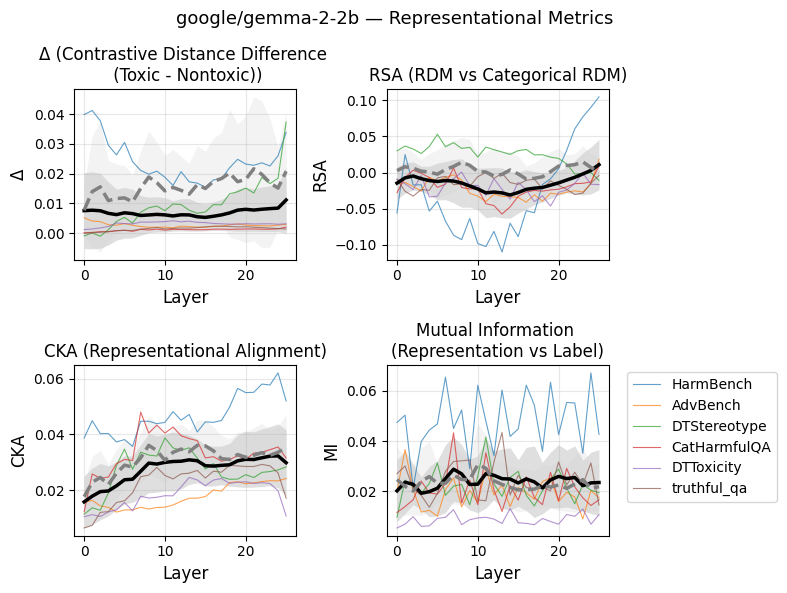


=== Processing model: meta-llama/Llama-3.2-3B ===

=== Processing model: meta-llama/Llama-3.2-3B ===


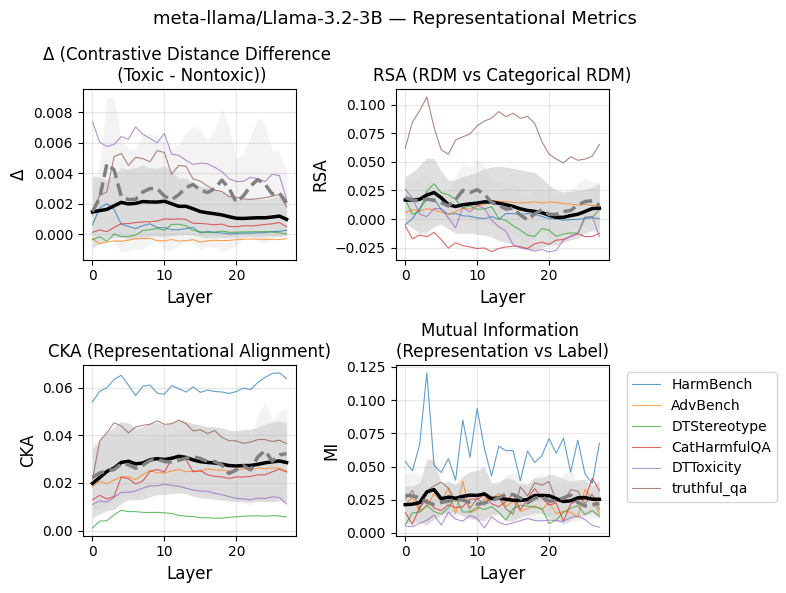


=== Processing model: google/gemma-2-2b-it ===

=== Processing model: google/gemma-2-2b-it ===


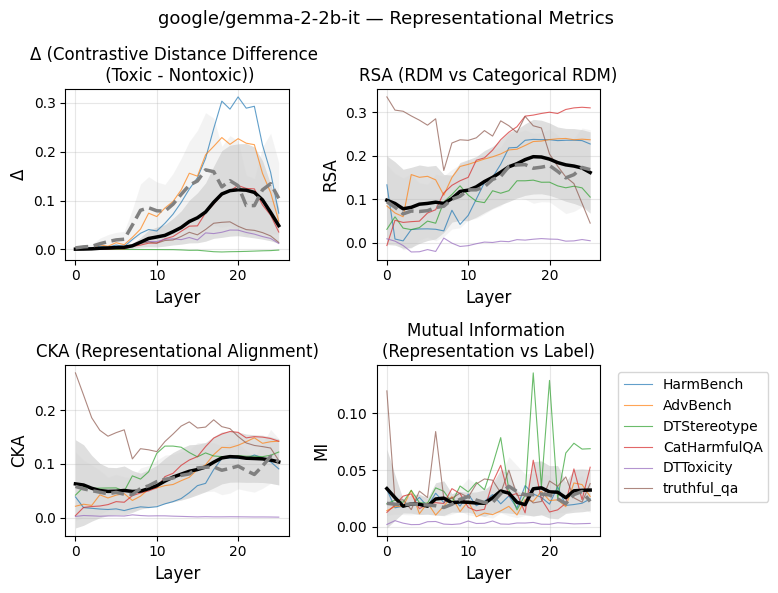


=== Processing model: meta-llama/Llama-3.2-3B-Instruct ===

=== Processing model: meta-llama/Llama-3.2-3B-Instruct ===


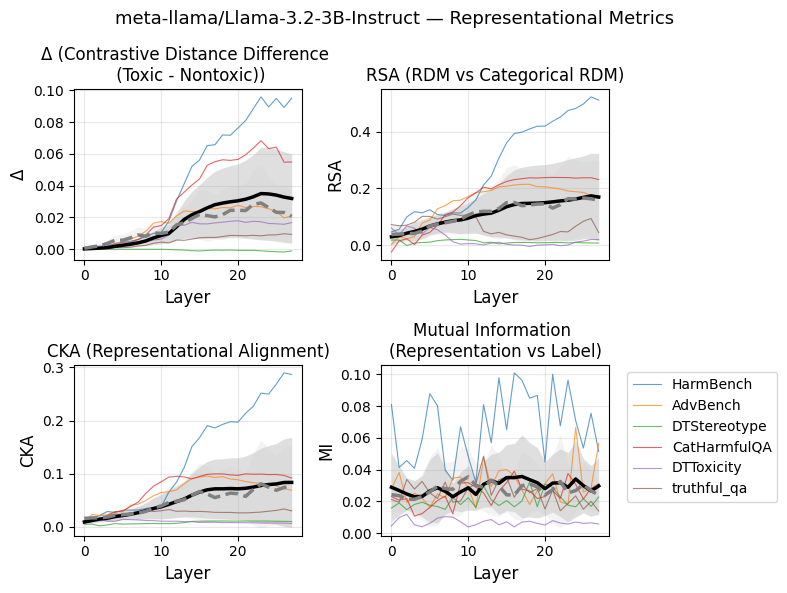


=== Processing model: Qwen/Qwen2.5-3B-Instruct ===

=== Processing model: Qwen/Qwen2.5-3B-Instruct ===


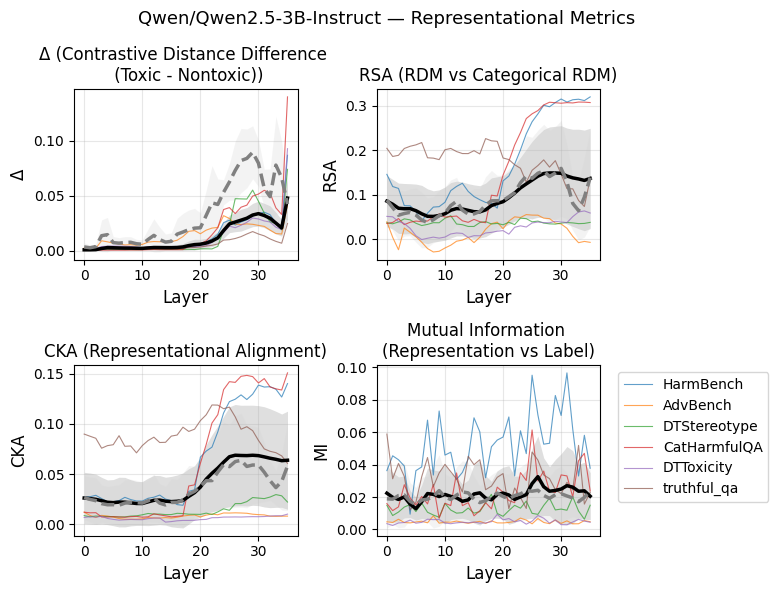


=== Processing model: Qwen/Qwen2.5-3B ===

=== Processing model: Qwen/Qwen2.5-3B ===


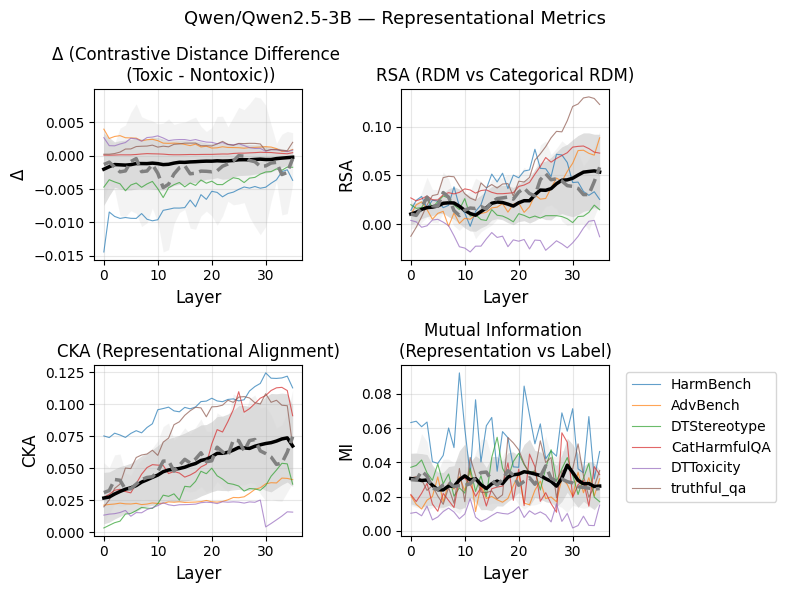

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mutual_info_score
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from scipy.stats import t
from scipy.stats import combine_pvalues
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

# --- Optional: CKA helper ---
def compute_cka(X, Y):
    """Centered Kernel Alignment between two representation matrices."""
    # X = X - X.mean(0, keepdims=True)
    # Y = Y - Y.mean(0, keepdims=True)
    Kx = X @ X.T
    # Ky = Y @ Y.T
    Ky = Y
    # hsic = np.sum(Kx * Ky)
    # norm = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    hsic = HSIC(Kx, Ky)
    norm = np.sqrt(HSIC(Kx, Kx) * HSIC(Ky, Ky))
    return hsic / norm

def HSIC(K, L):
    """Hilbert-Schmidt Independence Criterion."""
    m = K.shape[0]
    H = np.eye(m) - 1/m * np.ones((m, m))
    numerator = np.trace(K @ H @ L @ H)
    return numerator / (m - 1)**2

# --- Helper for RSA (C) ---
def upper_triangle(mat):
    return mat[np.triu_indices_from(mat, k=1)]


def rsa_corr(v_model, v_theory, method="pearson"):
    if method == "pearson":
        # point-biserial when v_theory is 0/1
        v1 = v_model.astype(float)
        v2 = v_theory.astype(float)
        v1 -= v1.mean(); v2 -= v2.mean()
        denom = np.linalg.norm(v1) * np.linalg.norm(v2)
        return 0.0 if denom == 0 else float(np.dot(v1, v2) / denom)
    elif method == "spearman":
        return float(spearmanr(v_model, v_theory).correlation)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")




def rsa_rdm(model_rdm, true_rdm):
    """RSA correlation (Spearman) between model and true categorical RDMs."""
    m = upper_triangle(model_rdm)
    t = upper_triangle(true_rdm)
    corr, _ = spearmanr(m, t)
    return corr

models = [ "google/gemma-2-2b", "meta-llama/Llama-3.2-3B","google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct",
           "Qwen/Qwen2.5-3B-Instruct",
           "Qwen/Qwen2.5-3B"]#, "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]
# --- Start analysis ---
for model in models:
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_11 ,X_1, v1 = load_harmbench_atten(model, output_dir)
    layers = sorted(list(X_1.keys()), key=lambda x: int(x.split('.')[2]))

    print(f"\n=== Processing model: {model} ===")
    results = {} #{'Δ': [], 'RSA': [], 'CKA': [], 'MI': []}
    p_list, null_list = [], []
    for layer in layers:
        X = X_1[layer].float().numpy()
        # X = X_11[layer].float().mean(1).numpy()
        # y = (v1 > 0).astype(int)
        y = v1.astype(int)
        results[layer] = {}

        # --- B. Contrastive Δ (mean distance difference) ---
        cos = cosine_similarity(X)
        dist_to_class_mean = []
        for c in [0, 1]:

            cls_vecs = X[y == c].mean(0, keepdims=True)
            dists = 1 - cosine_similarity(X, cls_vecs).squeeze()

            dist_to_class_mean.append(dists)
        Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
        results[layer]['Δ'] = [Δ]

        # --- C. RSA (model RDM vs. true categorical RDM) ---
        model_rdm = 1 - cosine_similarity(X)
        true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
        rsa_val = rsa_rdm(model_rdm, true_rdm)

        results[layer]['RSA'] = [rsa_val]

        # --- D. CKA (representational alignment with categorical kernel) ---
        y_vec = y.reshape(-1, 1)
        # cat_kernel = y_vec @ y_vec.T  # binary kernel
        # y_ = np.where(y <= 0, -1, 1).reshape(-1, 1)  # enforce ±1
        # cat_kernel = y_ @ y_.T
        cat_kernel = (y[:,None] == y[None,:]).astype(float)
        cka_val = compute_cka(X, cat_kernel)
        results[layer]['CKA'] = [cka_val]

        # --- E. Mutual Information (representation vs. label) ---
        # Flatten activations along feature axis for MI
        proj = X @ np.random.randn(X.shape[1], 1)  # random projection for stability
        proj_disc = np.digitize(proj.squeeze(), np.histogram(proj, bins=20)[1])
        mi_val = mutual_info_score(proj_disc, y)
        results[layer]['MI'] = [mi_val]

       

        for data in datasets_list:
            X_22, X_2, v2 = load_datasets_atten(model, data, output_dir)
            # v2 = (v2 > 0).astype(int)
            X = X_2[layer].float().numpy()
            # X = X_22[layer].float().mean(1).numpy()
            y = v2.astype(int)

            # --- B. Contrastive Δ (mean distance difference) ---
            cos = cosine_similarity(X)
            dist_to_class_mean = []
            for c in [0, 1]:
                cls_vecs = X[y == c].mean(0, keepdims=True)
                dists = 1 - cosine_similarity(X, cls_vecs).squeeze()
                dist_to_class_mean.append(dists)
            Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
            results[layer]['Δ'].append(Δ)

            # --- C. RSA (model RDM vs. true categorical RDM) ---
            model_rdm = 1 - cosine_similarity(X)
            true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
            rsa_val = rsa_rdm(model_rdm, true_rdm)
            results[layer]['RSA'].append(rsa_val)

            # --- D. CKA (representational alignment with categorical kernel) ---
            y_vec = y.reshape(-1, 1)
            # cat_kernel = y_vec @ y_vec.T  # binary kernel
            # y_ = np.where(y <= 0, -1, 1).reshape(-1, 1)  # enforce ±1
            # cat_kernel = y_ @ y_.T
            cat_kernel = (y[:,None] == y[None,:]).astype(float)
            cka_val = compute_cka(X, cat_kernel)
            results[layer]['CKA'].append(cka_val)

            # --- E. Mutual Information (representation vs. label) ---
            # Flatten activations along feature axis for MI
            proj = X @ np.random.randn(X.shape[1], 1)  # random projection for stability
            proj_disc = np.digitize(proj.squeeze(), np.histogram(proj, bins=20)[1])
            mi_val = mutual_info_score(proj_disc, y)
            results[layer]['MI'].append(mi_val)

          


    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_1, v1 = load_harmbench(model, output_dir)
    layers_f = sorted(list(X_1.keys()), key=lambda x: int(x.split('.')[-1]))

    print(f"\n=== Processing model: {model} ===")
    results_f = {} #{'Δ': [], 'RSA': [], 'CKA': [], 'MI': []}
    p_list, null_list = [], []
    for layer in layers_f:
        X = X_1[layer].float().numpy()
        # y = (v1 > 0).astype(int)
        y = v1.astype(int)
        results_f[layer] = {}

        # --- B. Contrastive Δ (mean distance difference) ---
        cos = cosine_similarity(X)
        dist_to_class_mean = []
        for c in [0, 1]:

            cls_vecs = X[y == c].mean(0, keepdims=True)
            dists = 1 - cosine_similarity(X, cls_vecs).squeeze()

            dist_to_class_mean.append(dists)
        Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
        results_f[layer]['Δ'] = [Δ]

        # --- C. RSA (model RDM vs. true categorical RDM) ---
        model_rdm = 1 - cosine_similarity(X)
        true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
        rsa_val = rsa_rdm(model_rdm, true_rdm)

        results_f[layer]['RSA'] = [rsa_val]

        # --- D. CKA (representational alignment with categorical kernel) ---
        y_vec = y.reshape(-1, 1)
        # cat_kernel = y_vec @ y_vec.T  # binary kernel
        # y_ = np.where(y <= 0, -1, 1).reshape(-1, 1)  # enforce ±1
        # cat_kernel = y_ @ y_.T
        cat_kernel = (y[:,None] == y[None,:]).astype(float)
        cka_val = compute_cka(X, cat_kernel)
        results_f[layer]['CKA'] = [cka_val]

        # --- E. Mutual Information (representation vs. label) ---
        # Flatten activations along feature axis for MI
        proj = X @ np.random.randn(X.shape[1], 1)  # random projection for stability
        proj_disc = np.digitize(proj.squeeze(), np.histogram(proj, bins=20)[1])
        mi_val = mutual_info_score(proj_disc, y)
        results_f[layer]['MI'] = [mi_val]

        
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            # v2 = (v2 > 0).astype(int)
            X = X_2[layer].float().numpy()
            y = v2.astype(int)

            # --- B. Contrastive Δ (mean distance difference) ---
            cos = cosine_similarity(X)
            dist_to_class_mean = []
            for c in [0, 1]:
                cls_vecs = X[y == c].mean(0, keepdims=True)
                dists = 1 - cosine_similarity(X, cls_vecs).squeeze()
                dist_to_class_mean.append(dists)
            Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
            results_f[layer]['Δ'].append(Δ)

            # --- C. RSA (model RDM vs. true categorical RDM) ---
            model_rdm = 1 - cosine_similarity(X)
            true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
            rsa_val = rsa_rdm(model_rdm, true_rdm)
            results_f[layer]['RSA'].append(rsa_val)

            # --- D. CKA (representational alignment with categorical kernel) ---
            y_vec = y.reshape(-1, 1)
            # cat_kernel = y_vec @ y_vec.T  # binary kernel
            # y_ = np.where(y <= 0, -1, 1).reshape(-1, 1)  # enforce ±1
            # cat_kernel = y_ @ y_.T
            cat_kernel = (y[:,None] == y[None,:]).astype(float)
            cka_val = compute_cka(X, cat_kernel)
            results_f[layer]['CKA'].append(cka_val)

            # --- E. Mutual Information (representation vs. label) ---
            # Flatten activations along feature axis for MI
            proj = X @ np.random.randn(X.shape[1], 1)  # random projection for stability
            proj_disc = np.digitize(proj.squeeze(), np.histogram(proj, bins=20)[1])
            mi_val = mutual_info_score(proj_disc, y)
            results_f[layer]['MI'].append(mi_val)


    # --- Plotting ---
    metrics = ['Δ', 'RSA', 'CKA', 'MI']
    titles = [
        'Δ (Contrastive Distance Difference \n (Toxic - Nontoxic))',
        'RSA (RDM vs Categorical RDM)',
        'CKA (Representational Alignment)',
        'Mutual Information \n(Representation vs Label)'
    ]
    
    datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    
    fig, axs = plt.subplots(2, 2, figsize=(8, 6))
    
    for i, metric in enumerate(metrics):
        ax = axs.flat[i]
        plt.sca(ax)

        
        
        plot_metric_ribbon(results_f, layers_f, metric=metric, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=datasets, linestyle='solid')
        
        plot_metric_ribbon(results, layers, metric=metric, color="lightgrey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=False, dataset_list=datasets, linestyle='dashed', color2='grey')
        
        ax.set_title(titles[i])
        ax.set_xlabel("Layer", fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.grid(alpha=0.3)
        # ax.tick_params(axis='x', rotation=45)

    plt.legend(datasets, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f"{model} — Representational Metrics", fontsize=13)
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_delta_atten_ffn.png",
                dpi=300, bbox_inches='tight')
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_delta_atten_ffn.svg",
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()



    



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mutual_info_score
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from scipy.stats import t
from scipy.stats import combine_pvalues
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

# --- Optional: CKA helper ---
def compute_cka(X, Y):
    """Centered Kernel Alignment between two representation matrices."""
    # X = X - X.mean(0, keepdims=True)
    # Y = Y - Y.mean(0, keepdims=True)
    Kx = X @ X.T
    # Ky = Y @ Y.T
    Ky = Y
    # hsic = np.sum(Kx * Ky)
    # norm = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    hsic = HSIC(Kx, Ky)
    norm = np.sqrt(HSIC(Kx, Kx) * HSIC(Ky, Ky))
    return hsic / norm

def HSIC(K, L):
    """Hilbert-Schmidt Independence Criterion."""
    m = K.shape[0]
    H = np.eye(m) - 1/m * np.ones((m, m))
    numerator = np.trace(K @ H @ L @ H)
    return numerator / (m - 1)**2

# --- Helper for RSA (C) ---
def upper_triangle(mat):
    return mat[np.triu_indices_from(mat, k=1)]


def rsa_corr(v_model, v_theory, method="pearson"):
    if method == "pearson":
        # point-biserial when v_theory is 0/1
        v1 = v_model.astype(float)
        v2 = v_theory.astype(float)
        v1 -= v1.mean(); v2 -= v2.mean()
        denom = np.linalg.norm(v1) * np.linalg.norm(v2)
        return 0.0 if denom == 0 else float(np.dot(v1, v2) / denom)
    elif method == "spearman":
        return float(spearmanr(v_model, v_theory).correlation)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")




def rsa_rdm(model_rdm, true_rdm):
    """RSA correlation (Spearman) between model and true categorical RDMs."""
    m = upper_triangle(model_rdm)
    t = upper_triangle(true_rdm)
    corr, _ = spearmanr(m, t)
    return corr

models = [ "google/gemma-2-2b", "meta-llama/Llama-3.2-3B","google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct",
           "Qwen/Qwen2.5-3B-Instruct",
           "Qwen/Qwen2.5-3B", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]
# --- Start analysis ---
for model in models:
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_1, v1 = load_harmbench(model, output_dir)
    layers = sorted(list(X_1.keys()), key=lambda x: int(x.split('.')[-1]))

    print(f"\n=== Processing model: {model} ===")
    results = {} #{'Δ': [], 'RSA': [], 'CKA': [], 'MI': []}
    p_list, null_list = [], []
    for layer in layers:
        X = X_1[layer].float().numpy()
        # y = (v1 > 0).astype(int)
        y = v1.astype(int)
        results[layer] = {}

        # --- B. Contrastive Δ (mean distance difference) ---
        cos = cosine_similarity(X)
        dist_to_class_mean = []
        for c in [0, 1]:

            cls_vecs = X[y == c].mean(0, keepdims=True)
            dists = 1 - cosine_similarity(X, cls_vecs).squeeze()

            dist_to_class_mean.append(dists)
        Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
        results[layer]['Δ'] = [Δ]

        # --- C. RSA (model RDM vs. true categorical RDM) ---
        model_rdm = 1 - cosine_similarity(X)
        true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
        rsa_val = rsa_rdm(model_rdm, true_rdm)

        results[layer]['RSA'] = [rsa_val]

        # --- D. CKA (representational alignment with categorical kernel) ---
        y_vec = y.reshape(-1, 1)
        # cat_kernel = y_vec @ y_vec.T  # binary kernel
        # y_ = np.where(y <= 0, -1, 1).reshape(-1, 1)  # enforce ±1
        # cat_kernel = y_ @ y_.T
        cat_kernel = (y[:,None] == y[None,:]).astype(float)
        cka_val = compute_cka(X, cat_kernel)
        results[layer]['CKA'] = [cka_val]

        # --- E. Mutual Information (representation vs. label) ---
        # Flatten activations along feature axis for MI
        proj = X @ np.random.randn(X.shape[1], 1)  # random projection for stability
        proj_disc = np.digitize(proj.squeeze(), np.histogram(proj, bins=20)[1])
        mi_val = mutual_info_score(proj_disc, y)
        results[layer]['MI'] = [mi_val]

        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            # v2 = (v2 > 0).astype(int)
            X = X_2[layer].float().numpy()
            y = v2.astype(int)

            # --- B. Contrastive Δ (mean distance difference) ---
            cos = cosine_similarity(X)
            dist_to_class_mean = []
            for c in [0, 1]:
                cls_vecs = X[y == c].mean(0, keepdims=True)
                dists = 1 - cosine_similarity(X, cls_vecs).squeeze()
                dist_to_class_mean.append(dists)
            Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
            results[layer]['Δ'].append(Δ)

            # --- C. RSA (model RDM vs. true categorical RDM) ---
            model_rdm = 1 - cosine_similarity(X)
            true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
            rsa_val = rsa_rdm(model_rdm, true_rdm)
            results[layer]['RSA'].append(rsa_val)

            # --- D. CKA (representational alignment with categorical kernel) ---
            y_vec = y.reshape(-1, 1)
            # cat_kernel = y_vec @ y_vec.T  # binary kernel

            cat_kernel = (y[:,None] == y[None,:]).astype(float)
            # y_ = np.where(y <= 0, -1, 1).reshape(-1, 1)  # enforce ±1
            # cat_kernel = y_ @ y_.T

            cka_val = compute_cka(X, cat_kernel)
            results[layer]['CKA'].append(cka_val)

            # --- E. Mutual Information (representation vs. label) ---
            # Flatten activations along feature axis for MI
            proj = X @ np.random.randn(X.shape[1], 1)  # random projection for stability
            proj_disc = np.digitize(proj.squeeze(), np.histogram(proj, bins=20)[1])
            mi_val = mutual_info_score(proj_disc, y)
            results[layer]['MI'].append(mi_val)

    # --- Plotting ---
    metrics = ['Δ', 'RSA', 'CKA', 'MI']
    titles = [
        'Δ (Contrastive Distance Difference \n (Toxic - Nontoxic))',
        'RSA (RDM vs Categorical RDM)',
        'CKA (Representational Alignment)',
        'Mutual Information \n(Representation vs Label)'
    ]
    datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    
    fig, axs = plt.subplots(2, 2, figsize=(8, 6))
    
    for i, metric in enumerate(metrics):
        ax = axs.flat[i]
        plt.sca(ax)

        plot_metric_ribbon(results, layers, metric=metric, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
        # for d, data in enumerate(['y/Harmbench'] + datasets_list):
        #     data_vals = [results[layer][metric][d] for layer in layers]

        #     ax.plot([int(l.split('.')[-1]) for l in layers], data_vals, marker='.', label=data.split('/')[-1])
        # ax.plot(layers, results[metric], marker='o', linewidth=2)
        ax.set_title(titles[i])
        ax.set_xlabel("Layer")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
        # ax.tick_params(axis='x', rotation=45)

    plt.legend(datasets, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f"{model} — Representational Metrics", fontsize=13)
    plt.tight_layout()
    # plt.show()
    # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_all_metrics.png",
    #             dpi=300, bbox_inches='tight')
    # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_all_metrics.svg",
    #             dpi=300, bbox_inches='tight')
    # plt.show()
    plt.close()



    



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from scipy.stats import spearmanr
from scipy.stats import pearsonr, t
from sklearn.feature_selection import mutual_info_regression

def scatter_rsa_vs_uor_colorbar(rsa_per_layer, uor_per_layer_alpha, alphas, max_alpha_len, model, alpha_max_val=5.0):
    """
    Scatter plot of UOR vs RSA across layers,
    with alpha encoded as a continuous red colorbar.

    rsa_per_layer: shape (L,)
    uor_per_layer_alpha: shape (L, A)
    alphas: shape (A,)
    Returns:
        corrs: Spearman correlation between RSA and UOR for each alpha.
    """
    rsa = np.asarray(rsa_per_layer, float)
    uor = np.asarray(uor_per_layer_alpha, float)
    alphas = np.asarray(alphas, float)

    L, A = uor.shape
    assert A == len(alphas), "Dimension mismatch: UOR shape must match len(alphas)."

    # --- Set up colormap: red gradient for alpha ---
    # norm = colors.Normalize(vmin=alphas.min(), vmax=alphas.max())
    # cmap = cm.Reds
    reds = cm.Reds(np.linspace(0.2, 0.9, max_alpha_len))
    colors_list = reds[:len(alphas)]
    cmap = colors.ListedColormap(reds)
    norm = colors.Normalize(vmin=alphas.min(), vmax=alpha_max_val)
    
    mi = mutual_info_regression(rsa.reshape(-1,1), uor.max(axis=1))
    print(f"Mutual Information RSA vs max UOR: {mi[0]:.4f}")

    # --- Compute correlations per alpha ---
    corrs = []
    p_vals = []
    fig, ax = plt.subplots(figsize=(4, 3.5))
    # for j, alpha in enumerate(alphas):
    #     u = uor[:, j]
    #     mask = np.isfinite(rsa) & np.isfinite(u)
    #     corr, p = spearmanr(rsa[mask], u[mask])
    #     corrs.append(corr)
    #     p_vals.append(p)

    #     # color = cmap(norm(alpha))
    #     color = colors_list[j]

    #     ax.scatter(rsa, u, color=color, s=5, alpha=0.2)

    # === Regression line using mean UOR across α ===
    x = rsa
    y = uor.max(axis=1)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    ax.scatter(x, y, color='black', s=5, alpha=0.5, label=r'$\bar{\alpha}$')
    # # Pearson r and p-value for the regression
    r_fit, p_fit = spearmanr(x, y)

    # Linear regression (ordinary least squares)
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ys = slope * xs + intercept
    ax.plot(xs, ys, color='black', linewidth=2)

    # === 95% confidence interval ===
    y_pred = slope * x + intercept
    resid = y - y_pred
    dof = len(x) - 2
    s_err = np.sqrt(np.sum(resid**2) / dof)

    t_val = t.ppf(0.975, dof)
    ci = t_val * s_err * np.sqrt(1/len(x) + (xs - np.mean(x))**2 / np.sum((x - np.mean(x))**2))

    ax.fill_between(xs, ys - ci, ys + ci, color='grey', alpha=0.25, linewidth=0, label='95% CI')

    # Assuming rsa has shape (L,) and uor has shape (L, A)
    L, A = uor.shape

    # 1. Flatten UOR (the Y-variable)
    # New shape (L*A,)
    y_all = uor.flatten() 

    # 2. Expand/Repeat RSA (the X-variable)
    # Each RSA_l value is repeated A times (for each alpha).
    # New shape (L*A,)
    x_all = np.repeat(rsa, A)
    # Apply the same masking/filtering (essential for removing NaNs)
    mask_all = np.isfinite(x_all) & np.isfinite(y_all)
    x_fit = x_all[mask_all]
    y_fit = y_all[mask_all]

    # Pearson r and p-value
    r_all, p_all = spearmanr(x_fit, y_fit)

    # Linear regression
    slope_all, intercept_all = np.polyfit(x_fit, y_fit, 1)

    # Now you can use slope_all and intercept_all to draw your line
    # 2. Define the x-range for the line
    xs_all = np.linspace(x_fit.min(), x_fit.max(), 200)

    # 3. Calculate the corresponding y-values for the line
    ys_all = slope_all * xs_all + intercept_all

    # 4. Plot the line on your axes (ax)
    # ax.plot(xs_all, ys_all, color='black', linewidth=2, label='Fit all points')
    # 1. Predict y-values for the actual x_fit data
    y_pred_all = slope_all * x_fit + intercept_all

    # 2. Calculate residuals
    resid_all = y_fit - y_pred_all

    # 3. Degrees of Freedom and Standard Error
    dof_all = len(x_fit) - 2
    s_err_all = np.sqrt(np.sum(resid_all**2) / dof_all)

    # 4. Critical t-value for 95% CI (two-tailed, 0.975 percentile)
    t_val_all = t.ppf(0.975, dof_all)

    # 5. Calculate the CI width (ci_all)
    # Use xs_all (the 200 points for plotting the line) for the CI calculation
    ci_all = t_val_all * s_err_all * np.sqrt(1/len(x_fit) + (xs_all - np.mean(x_fit))**2 / np.sum((x_fit - np.mean(x_fit))**2))

    # 6. Plot the filled area on your axes (ax)
    # ax.fill_between(xs_all, ys_all - ci_all, ys_all + ci_all, 
    #                 color='grey', alpha=0.25, linewidth=0, 
    #                 label='95% CI (all points)')

    # === Labels and title with Pearson r ===

    ax.set_xlabel("RSA")
    ax.set_ylabel("UOR")
    ax.set_title(f"RSA vs UOR, {model} \n r = {r_fit:.2f}, p = {p_fit:.3f}")

    # --- Colorbar that matches your colors_list ---
    
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    # cbar = plt.colorbar(sm)

    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax)
    # # cbar.ax.set_yticklabels([f"{a:.2f}" for a in alphas])
    # cbar.set_label(r"$\alpha$ (steering strength)")
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    
    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_vs_uor_colorbar.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_vs_uor_colorbar.svg", format='svg', dpi=300, bbox_inches='tight')
    plt.show()

    return np.array(corrs)


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import cm, colors
# from scipy.stats import spearmanr
# from scipy.stats import pearsonr, t
# from sklearn.linear_model import LinearRegression
# # from mpl_toolkits.mplot3d import Axes3D

# def calculate_p_values(X, Y, model):
#     """Calculates p-values for scikit-learn LinearRegression coefficients."""
#     # 1. Calculate Mean Squared Error (MSE)
#     predictions = model.predict(X)
#     resid = Y - predictions
#     MSE = np.sum(resid**2) / (len(X) - X.shape[1] - 1)

#     # 2. Calculate the design matrix (X) inverse product
#     # X_plus: The design matrix including the intercept column
#     X_plus = np.column_stack((X, np.ones(len(X))))
#     # (X'X)⁻¹
#     XTX_inv = np.linalg.inv(X_plus.T @ X_plus)
    
#     # 3. Calculate Standard Errors (SE)
#     # The diagonal of XTX_inv are proportional to the variance of the coefficient estimates
#     SE = np.sqrt(np.diag(XTX_inv) * MSE)
    
#     # 4. Calculate t-statistics (t = coeff / SE)
#     coefficients = np.append(model.coef_, model.intercept_) # [β₁, β₂, β₀]
#     t_stats = coefficients / SE
    
#     # 5. Calculate p-values (two-tailed test)
#     dof = len(X) - X.shape[1] - 1 # Degrees of freedom
#     p_values = (1 - t.cdf(np.abs(t_stats), dof)) * 2
    
#     # Return p-values for [β₁, β₂, β₀]
#     return p_values

# def scatter_rsa_vs_uor_colorbar(rsa_per_layer, uor_per_layer_alpha, alphas, max_alpha_len, model_name, alpha_max_val=5.0):
#     """
#     Scatter plot of UOR vs RSA across layers,
#     with alpha encoded as a continuous red colorbar.

#     rsa_per_layer: shape (L,)
#     uor_per_layer_alpha: shape (L, A)
#     alphas: shape (A,)
#     Returns:
#         corrs: Spearman correlation between RSA and UOR for each alpha.
#     """
#     rsa = np.asarray(rsa_per_layer, float)
#     uor = np.asarray(uor_per_layer_alpha, float)
#     alphas = np.asarray(alphas, float)

#     # L, A = uor.shape
#     # assert A == len(alphas), "Dimension mismatch: UOR shape must match len(alphas)."

#     # # --- Set up colormap: red gradient for alpha ---
#     # # norm = colors.Normalize(vmin=alphas.min(), vmax=alphas.max())
#     # # cmap = cm.Reds
#     # reds = cm.Reds(np.linspace(0.2, 0.9, max_alpha_len))
#     # colors_list = reds[:len(alphas)]
#     # cmap = colors.ListedColormap(reds)
#     # norm = colors.Normalize(vmin=alphas.min(), vmax=alpha_max_val)
    

#     # # --- Compute correlations per alpha ---
#     # corrs = []
#     # p_vals = []
#     # fig, ax = plt.subplots(figsize=(4, 3.5))
#     # for j, alpha in enumerate(alphas):
#     #     u = uor[:, j]
#     #     mask = np.isfinite(rsa) & np.isfinite(u)
#     #     corr, p = pearsonr(rsa[mask], u[mask])
#     #     corrs.append(corr)
#     #     p_vals.append(p)

#     #     # color = cmap(norm(alpha))
#     #     color = colors_list[j]

#     #     ax.scatter(rsa, u, color=color, s=5, alpha=0.2)

#     # # === Regression line using mean UOR across α ===
#     # x = rsa
#     # y = uor.mean(axis=1)

#     # mask = np.isfinite(x) & np.isfinite(y)
#     # x = x[mask]
#     # y = y[mask]
#     # ax.scatter(x, y, color='black', s=5, alpha=0.5, label=r'$\bar{\alpha}$')
   
#     L, A = uor.shape

    
#     # rsa: shape (L,)
#     # uor: shape (L, A)
#     # alphas: shape (A,)

#     # 1. Flatten UOR (the dependent variable, Y)
#     Y = uor.flatten() # Shape (L*A,)

#     # 2. Expand/Repeat RSA (independent variable X1)
#     X1_rsa = np.repeat(rsa, A) # Shape (L*A,)

#     # 3. Repeat alphas in blocks (independent variable X2)
#     X2_alpha = np.tile(alphas, L) # Shape (L*A,)

#     # Combine independent variables into a 2D feature matrix (X)
#     # X must have shape (L*A, 2)
#     X_data = np.column_stack((X1_rsa, X2_alpha))

#     # Handle NaNs/Infs (Crucial!)
#     mask = np.isfinite(X_data).all(axis=1) & np.isfinite(Y)
#     X_fit = X_data[mask]
#     Y_fit = Y[mask]

#     # Initialize and fit the model
#     model = LinearRegression()
#     model.fit(X_fit, Y_fit)
#     # Extract the results
#     beta_0 = model.intercept_
#     beta_1_rsa = model.coef_[0]
#     beta_2_alpha = model.coef_[1]
#     r_squared = model.score(X_fit, Y_fit)
#     # You can also get the Multiple Correlation Coefficient (R)
#     R_value = np.sqrt(r_squared)
#     # --- Calculate Standardized Beta (Beta*) ---
#     # SD (Standard Deviation) of the variables
#     SD_Y = np.std(Y_fit)
#     SD_X1_rsa = np.std(X_fit[:, 0]) # SD of RSA
#     SD_X2_alpha = np.std(X_fit[:, 1]) # SD of alpha

#     # Calculate Beta* for RSA and alpha
#     beta_star_1_rsa = beta_1_rsa * (SD_X1_rsa / SD_Y)
#     beta_star_2_alpha = beta_2_alpha * (SD_X2_alpha / SD_Y)

#     print(f"## 📊 MLR Results for {model_name}")
#     print(f"Model: UOR = {beta_0:.3f} + {beta_1_rsa:.3f} * RSA + {beta_2_alpha:.3f} * alpha")
#     print(f"R-squared (R²): {r_squared:.4f}")

#     print("\n### Coefficient Interpretation:")
#     print(f"β₁ (RSA): {beta_1_rsa:.4f} (Change in UOR per unit RSA, holding alpha constant)")
#     print(f"β₂ (alpha): {beta_2_alpha:.4f} (Change in UOR per unit alpha, holding RSA constant)")

#     print("\n### Standardized Coefficients (Beta*):")
#     print(f"Beta* (RSA): {beta_star_1_rsa:.4f} (Effect of RSA on UOR, relative to alpha)")
#     print(f"Beta* (alpha): {beta_star_2_alpha:.4f} (Effect of alpha on UOR, relative to RSA)")

#     print(f"## 📈 MLR Correlation Score")
#     print(f"Multiple R-squared (R²): {r_squared:.4f}")
#     print(f"Multiple R: {R_value:.4f}")

    
#     # Note: sklearn's LinearRegression *automatically* handles the intercept (β₀)
#     # unless you explicitly set fit_intercept=False.


#     # --- Usage Example ---
#     p_values = calculate_p_values(X_fit, Y_fit, model)

#     print("\n### P-values for Coefficients:")
#     print(f"p-value (RSA, β₁): {p_values[0]:.4f}")
#     print(f"p-value (alpha, β₂): {p_values[1]:.4f}")
#     print(f"p-value (Intercept, β₀): {p_values[2]:.4f}")
#     # 6. Plot the filled area on your axes (ax)
   
    


#     # 1. Define the range for the grid
#     rsa_min, rsa_max = X_fit[:, 0].min(), X_fit[:, 0].max()
#     alpha_min, alpha_max = X_fit[:, 1].min(), X_fit[:, 1].max()

#     # 2. Create the grid points
#     # Use np.linspace to create 50 points for RSA and alpha
#     rsa_grid = np.linspace(rsa_min, rsa_max, 50)
#     alpha_grid = np.linspace(alpha_min, alpha_max, 50)

#     # 3. Create a meshgrid
#     RSA_mesh, ALPHA_mesh = np.meshgrid(rsa_grid, alpha_grid)

#     # 4. Flatten the meshgrid for prediction
#     # X_pred_grid will have shape (50*50, 2)
#     X_pred_grid = np.column_stack([RSA_mesh.ravel(), ALPHA_mesh.ravel()])

#     # 5. Predict UOR across the grid
#     UOR_pred_flat = model.predict(X_pred_grid)

#     # 6. Reshape the predictions back to the grid structure
#     UOR_pred_mesh = UOR_pred_flat.reshape(RSA_mesh.shape)
#     # Create the 3D plot
#     # fig = plt.figure(figsize=(10, 8))
#     # ax = fig.add_subplot(111, projection='3d')
#     fig = plt.figure(figsize=(10, 8))
#     ax = fig.add_subplot(projection='3d')

    
#     reds = cm.Reds(np.linspace(0.2, 0.9, max_alpha_len))
#     colors_list = reds[:len(alphas)]
#     cmap = colors.ListedColormap(reds)
#     norm = colors.Normalize(vmin=alphas.min(), vmax=alpha_max_val)
#     colors_scatter = cmap(norm(X_fit[:, 1]))


#     # Scatter plot: (RSA, alpha, UOR)
#     ax.scatter(X_fit[:, 0], X_fit[:, 1], Y_fit, 
#             c=colors_scatter, 
#             s=8, 
#             alpha=0.6, )
#             # label='Data Points')

#     # --- 2. Plot the Regression Plane ---
#     # Plot the surface using the meshgrid data
#     ax.plot_surface(RSA_mesh, ALPHA_mesh, UOR_pred_mesh, 
#                     alpha=0.4, 
#                     cmap=cmap,) # Optionally color the plane by UOR
#                     # label='Regression Plane')

#     # --- 3. Labels and Titles ---
#     ax.set_xlabel('RSA')
#     ax.set_ylabel(r'$\alpha$ (Steering Strength)')
#     ax.set_zlabel('UOR')
#     ax.set_title(f'3D Regression Plane: UOR ~ RSA + $\\alpha$')

#     # Optional: Add a colorbar for alpha
#     sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm.set_array([])
#     cbar = fig.colorbar(sm, ax=ax, shrink=0.7)
#     cbar.set_label(r'$\alpha$ Value')

#     # Optional: Adjust viewing angle for better clarity
#     ax.view_init(elev=20, azim=130)

#     plt.show()
#     # 

#     # [Image of a 3D scatter plot showing a regression plane fitted to data points]
    





In [ ]:
def plot_binned_rsa_uor(rsa_per_layer, uor_per_layer_alpha, model, n_bins=8):
    rsa = np.asarray(rsa_per_layer, float)          # (L,)
    uor = np.asarray(uor_per_layer_alpha, float)    # (L, A)

    x = np.repeat(rsa, uor.shape[1])
    y = uor.flatten()

    bins = np.linspace(x.min(), x.max(), n_bins+1)
    idx = np.digitize(x, bins) - 1  # 0..n_bins-1

    bin_centers, y_means, y_stds = [], [], []
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() == 0: 
            continue
        bin_centers.append(x[mask].mean())
        y_means.append(y[mask].mean())
        y_stds.append(y[mask].std())

    bin_centers = np.array(bin_centers)
    y_means = np.array(y_means)
    y_stds = np.array(y_stds)

    plt.figure(figsize=(4,3.5))
    plt.errorbar(bin_centers, y_means, yerr=y_stds, fmt='o-', lw=2)
    plt.xlabel("RSA (binned)")
    plt.ylabel("Mean UOR")
    plt.title(f"Binned RSA vs UOR, {model}")
    plt.tight_layout()
    plt.show()


def plot_layerwise_rsa_uor(rsa_per_layer, uor_per_layer_alpha, model):
    rsa = np.asarray(rsa_per_layer, float)          # (L,)
    uor = np.asarray(uor_per_layer_alpha, float)    # (L, A)
    L = len(rsa)
    layers = np.arange(L)

    uor_mean = uor.max(axis=1)

    fig, ax1 = plt.subplots(figsize=(4,3.5))

    # RSA curve
    ax1.plot(layers, rsa, 'k-', lw=2, label='RSA')
    ax1.set_xlabel("Layer")
    ax1.set_ylabel("RSA", color='k')

    # UOR curve on second y-axis (normalize so scales are comparable)
    ax2 = ax1.twinx()
    uor_norm = (uor_mean - uor_mean.min()) / (uor_mean.max() - uor_mean.min() + 1e-8)
    ax2.plot(layers, uor_norm, color='red', lw=2, label='UOR (normalized)')
    ax2.set_ylabel("UOR (normalized)", color='red')

    fig.suptitle(f"Layerwise RSA & UOR, {model}")
    fig.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from scipy.stats import spearmanr
from scipy.stats import pearsonr, t
from sklearn.feature_selection import mutual_info_regression

def scatter_rsa_vs_uor_pn(rsa_per_layer, uor_per_layer_alpha_p, uor_per_layer_alpha_n, alphas_n, alphas_p, model, alpha_max_val=5.0):
    """
    Scatter plot of UOR vs RSA across layers,
    with alpha encoded as a continuous red colorbar.

    rsa_per_layer: shape (L,)
    uor_per_layer_alpha: shape (L, A)
    alphas: shape (A,)
    Returns:
        corrs: Spearman correlation between RSA and UOR for each alpha.
    """
    rsa = np.asarray(rsa_per_layer, float)
    uor_p = np.asarray(uor_per_layer_alpha_p, float)
    uor_n = np.asarray(uor_per_layer_alpha_n, float)
    # alphas_p = np.asarray(alphas_p, float)
    # alphas_n = np.asarray(alphas_n, float)

    # L, A = uor_p.shape
    # assert A == len(alphas_p), "Dimension mismatch: UOR shape must match len(alphas)."

    

    # --- Compute correlations per alpha ---
    corrs = []
    p_vals = []
    fig, ax = plt.subplots(figsize=(6, 3.5))
   
    # === Regression line using mean UOR across α ===
    x = rsa
    y = uor_p.max(axis=1)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    ax.scatter(x, y, color='red', s=5, alpha=0.5)#, label=r'$\alpha_\uparrow$')
    # # Pearson r and p-value for the regression
    # r_fit, p_fit = spearmanr(x, y)
    r_fit, p_fit = pearsonr(x, y)


    # Linear regression (ordinary least squares)
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ys = slope * xs + intercept
    ax.plot(xs, ys, color='red', linewidth=2, label=fr"$\alpha_\uparrow$: $r= {r_fit:.2f}, p = {p_fit:.3f}$")

    # === 95% confidence interval ===
    y_pred = slope * x + intercept
    resid = y - y_pred
    dof = len(x) - 2
    s_err = np.sqrt(np.sum(resid**2) / dof)

    t_val = t.ppf(0.975, dof)
    ci = t_val * s_err * np.sqrt(1/len(x) + (xs - np.mean(x))**2 / np.sum((x - np.mean(x))**2))

    ax.fill_between(xs, ys - ci, ys + ci, color='red', alpha=0.25, linewidth=0)#, label='95% CI')

    # === Regression line using mean UOR across α ===
    x = rsa
    y = uor_n.min(axis=1)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    ax.scatter(x, y, color='blue', s=5, alpha=0.5)#, label=r'$\alpha_\downarrow$')
    # # Pearson r and p-value for the regression
    # r_fitn, p_fitn = spearmanr(x, y)
    r_fitn, p_fitn = pearsonr(x, y)


    # Linear regression (ordinary least squares)
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ys = slope * xs + intercept
    ax.plot(xs, ys, color='blue', linewidth=2, label=fr"$\alpha_\downarrow$: $r= {r_fitn:.2f}, p = {p_fitn:.3f}$")

    # === 95% confidence interval ===
    y_pred = slope * x + intercept
    resid = y - y_pred
    dof = len(x) - 2
    s_err = np.sqrt(np.sum(resid**2) / dof)

    t_val = t.ppf(0.975, dof)
    ci = t_val * s_err * np.sqrt(1/len(x) + (xs - np.mean(x))**2 / np.sum((x - np.mean(x))**2))

    ax.fill_between(xs, ys - ci, ys + ci, color='blue', alpha=0.25, linewidth=0)#, label='95% CI')

    
    

    ax.set_xlabel("RSA")
    ax.set_ylabel("UOR")
    # ax.set_ylim(0.0, 1.0)
    # ax.set_aspect('equal')
    ax.set_title(f"RSA vs UOR, {model}") # \n r = {r_fit:.2f}, p = {p_fit:.3f}")

    plt.legend(bbox_to_anchor=(1.05, 1.05), ncol=1)

   
    # cbar.set_label(r"$\alpha$ (steering strength)")
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    
    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_vs_uor_pn.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_vs_uor_pn.svg", format='svg', dpi=300, bbox_inches='tight')
    plt.show()

    return np.array(corrs)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mutual_info_score
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from scipy.stats import t
from scipy.stats import combine_pvalues
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr


# --- Helper for RSA (C) ---
def upper_triangle(mat):
    return mat[np.triu_indices_from(mat, k=1)]

def rsa_rdm(model_rdm, true_rdm):
    """RSA correlation (Spearman) between model and true categorical RDMs."""
    m = upper_triangle(model_rdm)
    t = upper_triangle(true_rdm)
    corr, _ = spearmanr(m, t)
    return corr

def fisher_combine(rs):
    zs = np.arctanh(rs)
    return np.tanh(zs.mean())


alphas_p = [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.1, 1.2, 1.3, 1.4, 1.6, 1.8, 2.2, 2.4]
alphas_p += [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]  
alphas_p = sorted(alphas_p)
alphas_n = [-a for a in alphas_p]
alphas = alphas_p
pos_alpha = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.8, 2.0, 2.2 , 2.4]
neg_laphas = [-a for a in pos_alpha]
alpha_choose = pos_alpha



models = [ "google/gemma-2-2b", "meta-llama/Llama-3.2-3B","google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct",
           "Qwen/Qwen2.5-3B-Instruct",
           "Qwen/Qwen2.5-3B"]
        #    , "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]
max_alpha_len = len(alphas)
# --- Start analysis ---
for model in models:
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_1, v1 = load_harmbench(model, output_dir)
    layers = sorted(list(X_1.keys()), key=lambda x: int(x.split('.')[-1]))

    print(f"\n=== Processing model: {model} ===")
    results = {} #{'Δ': [], 'RSA': [], 'CKA': [], 'MI': []}
    rsa_m = {}
    auc_res = {}
    L = len(layers)
    A = len(alpha_choose)

    uor = np.zeros((L, A), dtype=float)   # (layers, alphas)
    uor_n = np.zeros((L, A), dtype=float)   # (layers, alphas)
    rsa = np.zeros(L, dtype=float)    

    base_uor = sum((v1 > 0).astype(int)) / len(v1)

    for li, layer in enumerate(layers):
        X = X_1[layer].float().numpy()
        # y = (v1 > 0).astype(int)
        y = v1.astype(int)
        results[layer] = {}
        rsa_m[layer] = []
        auc_res[layer] = []

        

        # --- C. RSA (model RDM vs. true categorical RDM) ---
        model_rdm = 1 - cosine_similarity(X)
        true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
        rsa_val = rsa_rdm(model_rdm, true_rdm)

        results[layer]['RSA'] = [rsa_val]

        for aj, a in enumerate(alpha_choose): 
            
            side = 'toxic'           
            labels_after = np.load(f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{a}.npy", allow_pickle=True).item()
           
            valid_lab = [r for r in labels_after[layer] if r != -1]
            avg_l = sum(valid_lab) / len(labels_after[layer])
            auc_res[layer].append(avg_l)
            # uor[li, aj] = avg_l

            if a < 0:
                measure_uor = base_uor - avg_l
            else:
                measure_uor = avg_l - base_uor

            uor[li, aj] = avg_l #measure_uor
                
        for aj, a in enumerate(neg_laphas): 
            
            side = 'toxic'           
            labels_after = np.load(f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{a}.npy", allow_pickle=True).item()
           
            valid_lab = [r for r in labels_after[layer] if r != -1]
            avg_l = sum(valid_lab) / len(labels_after[layer])
            auc_res[layer].append(avg_l)
            # uor[li, aj] = avg_l

            if a < 0:
                measure_uor = base_uor - avg_l
            else:
                measure_uor = avg_l - base_uor

            uor_n[li, aj] = avg_l #measure_uor
                
            

        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            # v2 = (v2 > 0).astype(int)
            X = X_2[layer].float().numpy()
            y = v2.astype(int)


            # --- C. RSA (model RDM vs. true categorical RDM) ---
            model_rdm = 1 - cosine_similarity(X)
            true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
            rsa_val = rsa_rdm(model_rdm, true_rdm)
            results[layer]['RSA'].append(rsa_val)
        
        r_val = np.mean(results[layer]['RSA'])

        uor_val = np.mean(auc_res[layer])
        # uor[li] = uor_val
        # r_val = results[layer]['RSA'][0]  # Harmbench RSA
        rsa[li] = r_val
    corr = scatter_rsa_vs_uor_pn(rsa, uor, uor_n, neg_laphas, alpha_choose, model, alpha_max_val=5.0)
    # corr = scatter_rsa_vs_uor_colorbar(rsa, uor, alpha_choose, max_alpha_len, model, alpha_max_val=5.0)
    # plot_binned_rsa_uor(rsa, uor, model, n_bins=8)
    # plot_layerwise_rsa_uor(rsa, uor, model)

    
            

   

    




=== Processing model: google/gemma-2-2b-it ===


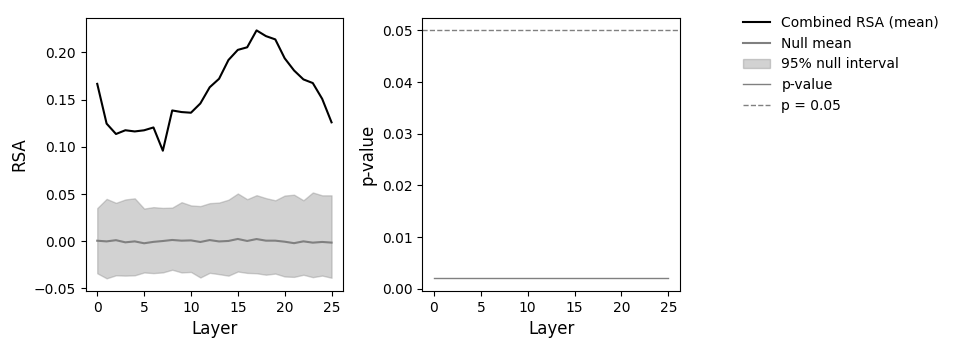


=== Processing model: meta-llama/Llama-3.2-3B-Instruct ===


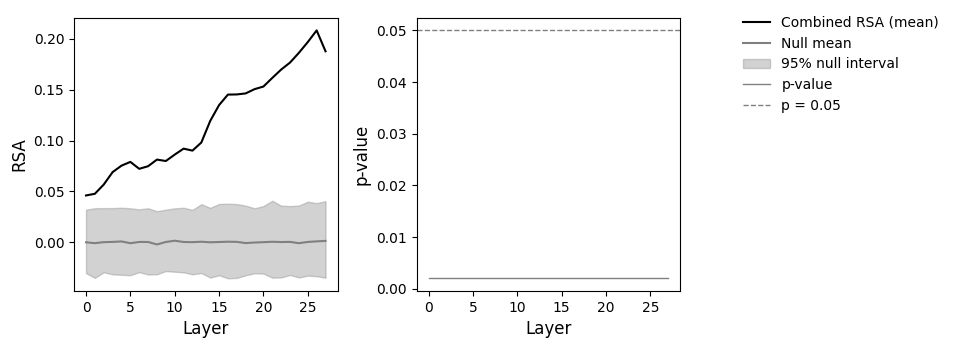


=== Processing model: Qwen/Qwen2.5-3B-Instruct ===


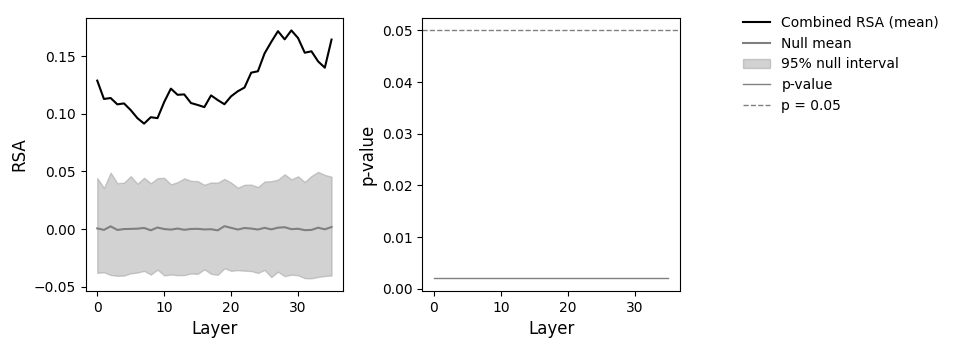


=== Processing model: Qwen/Qwen2.5-3B ===


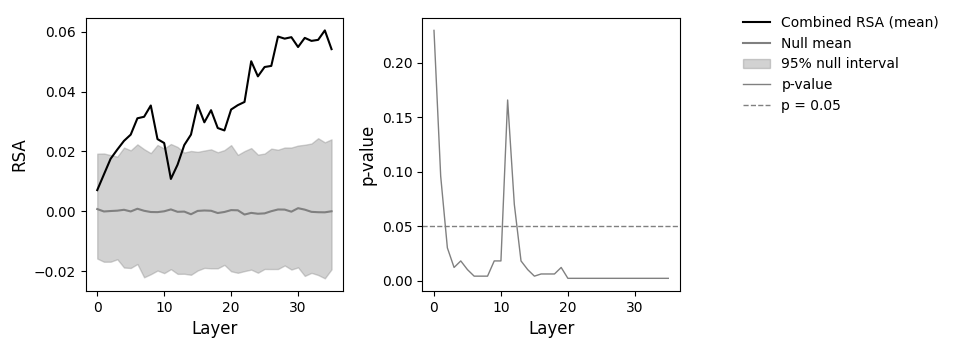


=== Processing model: allenai/OLMo-2-0425-1B ===


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mutual_info_score
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from scipy.stats import t
from scipy.stats import combine_pvalues
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from scipy.stats import rankdata

# --- Helper for RSA (C) ---
def upper_triangle(mat):
    return mat[np.triu_indices_from(mat, k=1)]


def rsa_corr(v_model, v_theory, method="pearson"):
    if method == "pearson":
        # point-biserial when v_theory is 0/1
        v1 = v_model.astype(float)
        v2 = v_theory.astype(float)
        v1 -= v1.mean(); v2 -= v2.mean()
        denom = np.linalg.norm(v1) * np.linalg.norm(v2)
        return 0.0 if denom == 0 else float(np.dot(v1, v2) / denom)
    elif method == "spearman":
        return float(spearmanr(v_model, v_theory).correlation)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

# def rsa_perm_test_with_labels(X, y, metric="cosine", method="pearson",
#                               n_perm=5000, tail="right", rng=0):
#     """
#     RSA permutation test where:
#       - mat1 = RDM from X (actual dissimilarities)
#       - mat2 = RDM from labels (0 same, 1 different)
#     We permute labels to form the null.
#     Returns: obs, pval, null_dist
#     """
#     rng = np.random.default_rng(rng)
#     R1 = 1 - cosine_similarity(X) # model RDM

#     # theoretical vector from true labels
#     v2 = 1.0 - (y[:, None] == y[None, :]).astype(float)
#     m = upper_triangle(R1)
#     t = upper_triangle(v2)
#     obs, _ = spearmanr(m, t)
#     # obs = rsa_rdm(R1, v2)

#     n = len(y)
#     null = np.empty(n_perm, dtype=float)
#     for b in range(n_perm):
#         y_perm = rng.permutation(y)
#         v2p = 1.0 - (y_perm[:, None] == y_perm[None, :]).astype(float)
#         # null[b] = rsa_rdm(R1, v2p)
#         null[b], _ = spearmanr(m, upper_triangle(v2p))

#     if tail == "right":
#         p = (1 + np.sum(null >= obs)) / (n_perm + 1)
#     elif tail == "left":
#         p = (1 + np.sum(null <= obs)) / (n_perm + 1)
#     else:  # two-sided
#         p = (1 + np.sum(np.abs(null) >= abs(obs))) / (n_perm + 1)

#     return obs, p, null
def triu_index(n):
    """Return i,j indices for the upper triangle (k=1)."""
    return np.triu_indices(n, k=1)

def rsa_perm_test_with_labels(X, y, method="spearman",
                              n_perm=5000, tail="right", rng=0):
    """
    RSA permutation test:
      - model vector: pairwise dissimilarities from X (cosine)
      - theory vector: 0/1, different/same labels from y
    Permutes labels to form the null.
    Returns: obs, pval, null_dist
    """
    n = len(y)

    # 1) Model RDM as condensed vector (no NxN matrix)
    m = pdist(X, metric="cosine").astype(np.float32)  # shape (P,)

    # 2) Precompute upper-triangle indices once
    ii, jj = triu_index(n)

    # 3) Observed label-RDM vector (0 same, 1 different)
    t = (y[ii] != y[jj]).astype(np.float32)

    # 4) Observed correlation
    if method == "pearson":
        obs = rsa_corr(m, t, method="pearson")
    elif method == "spearman":
        # Spearman via ranking m only once
        m_rank = rankdata(m).astype(np.float32)
        obs, _ = spearmanr(m_rank, t)   # or rsa_corr on ranks
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    # 5) Null distribution: reuse m, only change t via permuted labels
    null = np.empty(n_perm, dtype=np.float32)
    for b in range(n_perm):
        yp = rng.permutation(y)
        tp = (yp[ii] != yp[jj]).astype(np.float32)
        if method == "pearson":
            null[b] = rsa_corr(m, tp, method="pearson")
        else:
            null[b], _ = spearmanr(m, tp)

    # 6) p-value
    if tail == "right":
        p = (1 + np.sum(null >= obs)) / (n_perm + 1)
    elif tail == "left":
        p = (1 + np.sum(null <= obs)) / (n_perm + 1)
    else:  # two-sided
        p = (1 + np.sum(np.abs(null) >= abs(obs))) / (n_perm + 1)

    return float(obs), float(p), null


def rsa_rdm(model_rdm, true_rdm):
    """RSA correlation (Spearman) between model and true categorical RDMs."""
    m = upper_triangle(model_rdm)
    t = upper_triangle(true_rdm)
    corr, _ = spearmanr(m, t)
    return corr

models = [ #"google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "google/gemma-2-2b-it", 
            "meta-llama/Llama-3.2-3B-Instruct",
           "Qwen/Qwen2.5-3B-Instruct",
           "Qwen/Qwen2.5-3B", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]
# --- Start analysis ---

datasets_list = ["walledai/DTStereotype", "truthfulqa/truthful_qa"] #"walledai/AdvBench",
for model in models:
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_1, v1 = load_harmbench(model, output_dir)
    layers = sorted(list(X_1.keys()), key=lambda x: int(x.split('.')[-1]))
    XD_2, vd2 = [], []
    for data in datasets_list:
        x_2, v_2 = load_datasets(model, data, output_dir)
        XD_2.append(x_2)
        vd2.append(v_2)

    print(f"\n=== Processing model: {model} ===")
    results = {} #{'Δ': [], 'RSA': [], 'CKA': [], 'MI': []}
    p_list, null_list = [], []
    null_se = []
    combined_obs_list = []   # combined RSA per layer
    p_list, null_list = [], []
    n_perm = 500
    for layer_idx, layer in enumerate(layers):
        rng = np.random.default_rng(42)
        rng = np.random.default_rng(42 + 1000*layer_idx + 0)


        p_l = []
        null_l = []
        obs_l = []

        X = X_1[layer].float().numpy()
        # y = (v1 > 0).astype(int)
        y = v1.astype(int)
        results[layer] = {}

       
        rsa_val, pval, null = rsa_perm_test_with_labels(X, y, n_perm=n_perm, tail="right", rng=rng)

        p_l.append(pval)
        null_l.append(null)
        results[layer]['RSA'] = [rsa_val]
        obs_l.append(rsa_val)

       

        for i,data in enumerate(datasets_list):
            # X_2, v2 = load_datasets(model, data, output_dir)
            X_2 = XD_2[i]
            v2 = vd2[i]
            # v2 = (v2 > 0).astype(int)
            X = X_2[layer].float().numpy()
            y = v2.astype(int)

            rsa_val, pval, null = rsa_perm_test_with_labels(X, y, n_perm=n_perm, tail="right", rng=rng)           

            results[layer]['RSA'].append(rsa_val)

            p_l.append(pval)
            null_l.append(null)
            obs_l.append(rsa_val)


        p_combined = combine_pvalues(p_l, method='fisher')[1]
        
        null_l = np.vstack(null_l)
        # null_means = null_l.mean(axis=0)  # shape (n_perm,)
        obs_l = np.array(obs_l, dtype=float)    

        combined_obs = obs_l.mean()
        combined_null = null_l.mean(axis=0)  

        combined_p = (1 + np.sum(combined_null >= combined_obs)) / (n_perm + 1)


        combined_obs_list.append(combined_obs)
        p_list.append(combined_p)
        null_list.append(combined_null)



    

    # --- compute null stats ---
    layer_ids = np.arange(1, len(layers) + 1)

    # observed RSA per layer for HarmBench (the 0-th entry you stored)
    observed_rsa = np.array([results[layer]['RSA'][0] for layer in layers], dtype=float)
    rsa_null = np.column_stack(null_list)  # (n_perm, L)

    # p-values per layer as array shape (L,)
    p_values = np.array(p_list, dtype=float)
    null_sd = rsa_null.std(axis=0, ddof=1)

    # n_perm = rsa_null.shape[0]
    null_mean = rsa_null.mean(axis=0)

    combined_rsa_obs = np.array(combined_obs_list)
    rsa_null = np.column_stack(null_list)  # (n_perm, L)
    null_mean = rsa_null.mean(axis=0)
    null_sd   = rsa_null.std(axis=0, ddof=1)
    p_values  = np.array(p_list)

    low  = np.percentile(rsa_null, 2.5, axis=0)
    high = np.percentile(rsa_null, 97.5, axis=0)

    # --- plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7,3.5))
                                # gridspec_kw={'height_ratios':[3,1]})

    # Top: observed vs null CI
    ax1.plot(range(len(layers)), combined_rsa_obs, lw=1.5, color='black', label='Combined RSA (mean)')

    ax1.plot(range(len(layers)), null_mean,   color='grey', lw=1.5, label=r'Null mean')
    # ax1.fill_between(range(len(layers)), null_mean - null_sd, null_mean + null_sd, color='gray', alpha=0.35, label='±1 SD')
    ax1.fill_between(range(len(layers)), low, high, color='gray', alpha=0.35, label='95% null interval')

   
    ax1.set_ylabel('RSA', fontsize=12)
    # ax1.set_ylim([-0.1, 0.1])
    ax1.set_xlabel('Layer', fontsize=12)
   
    ax2.plot(range(len(layers)), p_values, color='grey', lw=1, label='p-value')
    ax2.axhline(0.05, color='grey', ls='--', lw=1, label='p = 0.05')
    ax2.set_ylabel('p-value', fontsize=12)
    ax2.set_xlabel('Layer', fontsize=12)
    # ax2.legend(frameon=False, loc='upper right')
    handles, labels = [], []
    for ax in [ax1, ax2]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    fig.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    # plt.suptitle(f"{model}")
    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_null_analysis_all_{n_perm}.png",
                dpi=300, bbox_inches='tight')
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_null_analysis_all_{n_perm}.svg",
                dpi=300, bbox_inches='tight')
    plt.show()

    


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import rankdata

def triu_index(n):
    """Return i,j indices for the upper triangle (k=1)."""
    ii, jj = np.triu_indices(n, k=1)
    return ii, jj

def rdm_vec_from_labels(y, ii, jj):
    """Vectorized categorical RDM (0 same, 1 different) for pairs (ii,jj)."""
    return (y[ii] != y[jj]).astype(np.float32)  # shape (P,), P = len(ii)

def spearman_against_binary_rdm(model_rdm_vec, y, ii, jj):
    """
    Spearman corr between model RDM (vector) and categorical RDM from labels y.
    Implemented as Pearson(rank(model_rdm_vec), categorical_vector).
    """
    x_rank = rankdata(model_rdm_vec).astype(np.float32)  # ranks 1..P
    x_rank -= x_rank.mean()
    x_rank /= np.linalg.norm(x_rank) + 1e-12

    t = rdm_vec_from_labels(y, ii, jj)
    t -= t.mean()
    t /= (np.linalg.norm(t) + 1e-12)

    return float(np.dot(x_rank, t))  # Pearson on standardized vectors

def rsa_perm_null_fast(model_rdm_vec, y, perms, ii, jj):
    """
    Fast permutation null for Spearman RSA:
      - model_rdm_vec: vectorized model RDM (P,)
      - y: (n,)
      - perms: (B, n) array of permuted indices for y
      - ii, jj: upper-tri indices for pairs
    Returns: (obs, null) where null is (B,)
    """
    # precompute ranked/standardized model vector once
    x_rank = rankdata(model_rdm_vec).astype(np.float32)
    x_rank -= x_rank.mean()
    x_rank /= np.linalg.norm(x_rank) + 1e-12

    # constants for standardizing binary RDM vectors (mean/std same for all perms)
    n = len(y)
    n1 = y.sum()
    n0 = n - n1
    P = len(ii)
    k = n0 * n1                          # number of 1s in categorical RDM
    mu_t = k / P
    sigma_t = np.sqrt(mu_t * (1 - mu_t)) + 1e-12

    # observed (use given y)
    t_obs = rdm_vec_from_labels(y, ii, jj)
    t_obs = (t_obs - mu_t) / sigma_t
    obs = float(np.dot(x_rank, t_obs))

    # null in batch using precomputed permutations
    B = perms.shape[0]
    null = np.empty(B, dtype=np.float32)
    for b in range(B):
        yp = y[perms[b]]
        tp = rdm_vec_from_labels(yp, ii, jj)   # (P,)
        tp = (tp - mu_t) / sigma_t
        null[b] = np.dot(x_rank, tp)

    return obs, null


In [ ]:
from scipy.stats import combine_pvalues, t

N_PERM = 500  # keep as-is, but you can drop to 300 with this speedup

# Precompute (and cache) permutations per dataset length
_perm_cache = {}  # key: n, value: (N_PERM, n) integer index permutations
def get_perms(n, rng=42):
    if n not in _perm_cache:
        rng = np.random.default_rng(rng)
        base = np.arange(n)
        _perm_cache[n] = np.vstack([rng.permutation(base) for _ in range(N_PERM)])
    return _perm_cache[n]

for model in models:
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    print(f"\n=== Processing model: {model} ===")

    # ---- load all datasets ONCE per model ----
    # dict[layer_name] -> activations
    X_h, y_h = load_harmbench(model, output_dir)      # y_h must be 0/1 ints
    D_all = {'HarmBench': (X_h, y_h.astype(int))}

    for data in datasets_list:
        X_d, y_d = load_datasets(model, data, output_dir)
        D_all[data.split('/')[-1]] = (X_d, y_d.astype(int))

    # consistent layer order
    layers = sorted(X_h.keys(), key=lambda x: int(x.split('.')[-1]))
    L = len(layers)

    # storage
    results = {layer: {'RSA': []} for layer in layers}
    p_list, pooled_null_list = [], []

    # ---- per-layer work ----
    for layer in layers:
        # build model RDM vector ONCE per dataset/layer
        per_dataset = []
        nulls_per_dataset = []
        pvals_per_dataset = []

        for dname, (Xdict, y) in D_all.items():
            X = Xdict[layer].float().numpy()
            n = len(y)
            ii, jj = triu_index(n)

            # model RDM (vector)
            R = 1.0 - cosine_similarity(X)
            mvec = R[ii, jj].astype(np.float32)

            # reuse permutations for this n
            perms = get_perms(n)

            # fast RSA (obs + null)
            obs, null = rsa_perm_null_fast(mvec, y, perms, ii, jj)

            # right-tailed p (change if you want two-tailed)
            p = (1 + np.sum(null >= obs)) / (N_PERM + 1)

            # store
            results[layer]['RSA'].append(obs)
            pvals_per_dataset.append(p)
            nulls_per_dataset.append(null)
            per_dataset.append((obs, n))

        # combine p-values across datasets (Fisher)
        p_combined = combine_pvalues(pvals_per_dataset, method='fisher')[1]
        p_list.append(p_combined)

        # pooled null across datasets via Fisher-z / Stouffer-like meta
        obs_list = [o for (o, _) in per_dataset]
        n_list   = [n for (_, n) in per_dataset]
        # weight by sqrt(#pairs)
        w = np.sqrt(np.array([n*(n-1)//2 for n in n_list], dtype=float))
        w_norm = np.sqrt((w**2).sum())

        # stack nulls: shape (D, B)
        Nmat = np.vstack(nulls_per_dataset)
        Z_null = np.arctanh(np.clip(Nmat, -0.999999, 0.999999))
        z_null_comb = (w[:, None] * Z_null).sum(axis=0) / w_norm
        pooled_null_list.append(z_null_comb)

    # ---- compute layer curves for plotting ----
    layer_ids = np.arange(1, L+1)
    # HarmBench observed RSA per layer
    observed_rsa = np.array([results[layer]['RSA'][0] for layer in layers], dtype=float)
    # pooled null per layer (B x L) from the meta combination above
    rsa_null = np.column_stack(pooled_null_list)                 # z-space
    # convert pooled null back to r-space if you prefer (not necessary for CI on z):
    rsa_null_r = np.tanh(rsa_null)

    p_values = np.array(p_list, dtype=float)
    n_perm = rsa_null_r.shape[0]
    null_mean = rsa_null_r.mean(axis=0)
    null_sd   = rsa_null_r.std(axis=0, ddof=1)
    se        = null_sd / np.sqrt(n_perm)
    # ci
    t_val = t.ppf(0.975, df=n_perm - 1)
    ci_lo = null_mean - t_val * se
    ci_hi = null_mean + t_val * se

    # ---- plotting (with proper shared legend) ----
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.5))

    ax1.plot(range(L), null_mean, color='black', lw=1.2, label=r'$\overline{H_0}$')
    ax1.fill_between(range(L), ci_lo, ci_hi, color='gray', alpha=0.18, label='95% CI')
    ax1.set_ylabel('RSA'); ax1.set_xlabel('Layer')

    ax2.plot(range(L), p_values, color='black', lw=1.2, label='p-value')
    ax2.axhline(0.05, color='gray', ls='--', lw=1, label='p = 0.05')
    ax2.set_ylabel('p-value'); ax2.set_xlabel('Layer')

    # shared legend
    handles, labels = [], []
    for ax in (ax1, ax2):
        h, l = ax.get_legend_handles_labels()
        handles += h; labels += l
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)
    plt.subplots_adjust(bottom=0.20, wspace=0.35)
    plt.suptitle(f"{model}")
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_null_analysis_all.png",
    #             dpi=300, bbox_inches='tight')
    # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_null_analysis_all.svg",
    #             dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from scipy.stats import spearmanr, pearsonr
import numpy as np
import matplotlib.pyplot as plt
import re

models = [( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
          ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]

def rdm(X):
    return 1 - cosine_similarity(X)

def rsa_similarity_from_X(X1, X2, method='spearman'):
    R1, R2 = rdm(X1), rdm(X2)
    i, j = np.triu_indices_from(R1, k=1)
    v1, v2 = R1[i, j], R2[i, j]
    if method == 'spearman':
        corr, _ = spearmanr(v1, v2)
    elif method == 'pearson':
        corr, _ = pearsonr(v1, v2)
    else:
        raise ValueError(f"Unknown method {method}")
    return corr

def numpy_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    Kx, Ky = linear_kernel(X), linear_kernel(Y)
    hsic = np.sum(Kx * Ky)
    denom = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    return hsic / denom

for pair in models:
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))


    res = {}
    res_all = {}
    for layer in layer_names:
        if layer not in X_1i:
            print(f"[WARN] Layer {layer} missing in {model_it}; skipping.")
            continue
        cos_sim = {'spearman': [], 'pearson': [], 'cka': []}
        # Build combined matrices in the SAME dataset order for both models
        X_b = X_1b[layer].float().numpy() #@ steering_vector_a[layer]['toxic'].float().numpy()
        X_i = X_1i[layer].float().numpy() #@ steering_vector_b[layer]['toxic'].float().numpy()
        for method in ['spearman', 'pearson', 'cka']:
            if method == 'cka':
                sim = numpy_cka(X_b, X_i)
            else:
                sim = rsa_similarity_from_X(X_b, X_i, method=method)
            cos_sim[method].append(sim)
            print(f"{pair} | {layer} | Harmbench | {method}: {sim:.4f}")

        # Other datasets — must be appended in the same order for both models
        for ds in datasets_list:
            X_2b, _ = load_datasets(model_base, ds, output_dir)
            X_2i, _ = load_datasets(model_it, ds, output_dir)

            if layer not in X_2b or layer not in X_2i:
                print(f"[WARN] {layer} missing for {ds}; skipping that dataset for this layer.")
                continue
            # (Optional) assert equal n:
            if X_2b[layer].shape[0] != X_2i[layer].shape[0]:
                print(f"[WARN] Sample count mismatch for {ds} at {layer}; skipping.")
                continue
            X_b = X_2b[layer].float().numpy() #@ steering_vector_a[layer]['toxic'].float().numpy()
            X_i = X_2i[layer].float().numpy() #@ steering_vector_b[layer]['toxic'].float().numpy()
            for method in ['spearman', 'pearson', 'cka']:
                if method == 'cka':
                    sim = numpy_cka(X_b, X_i)
                else:
                    sim = rsa_similarity_from_X(X_b, X_i, method=method)
                cos_sim[method].append(sim)
                print(f"{pair} | {layer} | {ds} | {method}: {sim:.4f}")

        

        res[layer] = {}
        res_all[layer] = {}
        for method in ['spearman', 'pearson', 'cka']:
            sim = np.mean(cos_sim[method])
            res[layer][method] = sim
            res_all[layer][method] = cos_sim[method]
            print(f"{pair} | {layer} | {method}: {sim:.4f}")

    # ---- Plot per pair ----
    plot_layers = [ln for ln in layer_names if ln in res]
    x = [int(l.split('.')[-1]) for l in plot_layers]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
    axes = axes.flatten()
    datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, metric in enumerate(['spearman', 'pearson', 'cka']):
        ax = axes[i]
        # y = [res[l][metric] for l in plot_layers]
        # ax.plot(x, y, marker='o')
        # ax.set_title(metric.upper())
        # ax.set_xlabel("Layer index")
        # ax.set_ylabel("Similarity")
        # ax.grid(alpha=0.3)
        
        plt.sca(ax)
        plot_metric_ribbon(res_all, plot_layers, metric=metric, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
                
        plt.xlabel("Layer")
        plt.ylabel("Score")
        plt.title(f"Metric: {metric.upper()}")
        # plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)

    plt.legend(datasets, bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.suptitle(f"Cross-model RSA/CKA — {model_base} vs {model_it}")
    fig.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_base}_vs_{safe_it}_cross_model_rsa_cka.png",
                dpi=300, bbox_inches='tight')
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_base}_vs_{safe_it}_cross_model_rsa_cka.svg",
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from scipy.stats import spearmanr, pearsonr
import numpy as np
import matplotlib.pyplot as plt
import re

models = ["meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b-it", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B-Instruct"]

def rdm(X):
    return 1 - cosine_similarity(X)

def rsa_similarity_from_X(X1, X2, method='spearman'):
    R1, R2 = rdm(X1), rdm(X2)
    i, j = np.triu_indices_from(R1, k=1)
    v1, v2 = R1[i, j], R2[i, j]
    if method == 'spearman':
        corr, _ = spearmanr(v1, v2)
    elif method == 'pearson':
        corr, _ = pearsonr(v1, v2)
    else:
        raise ValueError(f"Unknown method {method}")
    return corr

def numpy_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    Kx, Ky = linear_kernel(X), linear_kernel(Y)
    hsic = np.sum(Kx * Ky)
    denom = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    return hsic / denom

X_all = {}
for model in models:
    X_all[model] = []
    X_1, v1 = load_harmbench(model, output_dir)
    safe_model = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_all[model].append(X_1)

    for ds in datasets_list:
        X_2, _ = load_datasets(model, ds, output_dir)
        X_all[model].append(X_2)


    res = {}
    res_all = {}
for model1 in models:
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))#, sharex=True)
    plot_idx = 0
    for model2 in models:
        res = {}
        if model1 == model2:
            continue
        
        pair = (model1, model2)
        layers_1 = sorted(list(X_all[model1][0].keys()), key=lambda x: int(x.split('.')[-1]))
        layers_2 = sorted(list(X_all[model2][0].keys()), key=lambda x: int(x.split('.')[-1]))
       
        middle_1 = len(layers_1) // 2
        middle_2 = len(layers_2) // 2
        
        choose_layers_2 = layers_2[:5] + layers_2[middle_2 - 5:middle_2 + 5] + layers_2[-5:]
        choose_layers_1 = layers_1[:5] + layers_1[middle_1 - 5:middle_1 + 5] + layers_1[-5:]
        # middle_layers1 = [layers_1[i] for i in np.linspace(6, len(layers_1) - 6, 10, dtype=int)]
        # middle_layers2 = [layers_2[i] for i in np.linspace(6, len(layers_2) - 6, 10, dtype=int)]
        # choose_layers_2 = layers_2[:5] + middle_layers2 + layers_2[-5:]
        # choose_layers_1 = layers_1[:5] + middle_layers1 + layers_1[-5:]
        for i, (layer1, layer2) in enumerate(zip(choose_layers_1, choose_layers_2)):
            res[f'reference.layer.{i}'] = {}
            cos = {}
            for method in ['spearman', 'pearson', 'cka']:
                res[f'reference.layer.{i}'][method] = []
                cos[method] = []
            for d, data in enumerate(['w/Harmbench'] + datasets_list):
                X_1 = X_all[model1][d][layer1]
                X_2 = X_all[model2][d][layer2]
                for method in ['spearman', 'pearson', 'cka']:
                    if method == 'cka':
                        sim = numpy_cka(X_1.float().numpy(), X_2.float().numpy())
                    else:
                        sim = rsa_similarity_from_X(X_1.float().numpy(), X_2.float().numpy(), method=method)
                    cos[method].append(sim)


            for method in ['spearman', 'pearson', 'cka']:

                res[f'reference.layer.{i}'][method] = cos[method]
                    # print(f"{pair} | Layer1: {layer1} | Layer2: {layer2} | {data} | {method}: {sim:.4f}")
        # ---- Plot per pair ----
        plot_layers = list(res.keys())
        # x = [int(l.split('.')[-1]) for l in plot_layers]
        print(plot_layers)
        # fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True)
        # axes = axes.flatten()
        datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
        for i, metric in enumerate(['spearman', 'pearson', 'cka']):
            ax = axes[plot_idx][i]
            
            plt.sca(ax)
            plot_metric_ribbon(res, plot_layers, metric=metric, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                            smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
                    
            # plt.xlabel("Layer")
            plt.ylabel("Score")
            plt.title(f"Metric: {metric.upper()}\n {model2}")
            ax.set_xticks(range(len(plot_layers)))
            ax.set_xticklabels([int(layer.split('.')[-1]) for layer in choose_layers_1], rotation=90, ha="right")

            ax2= ax.twiny()
            
            ax2.xaxis.set_ticks_position('bottom')
            ax2.xaxis.set_label_position('bottom')
            ax2.spines['bottom'].set_position(('outward', 35))  # shift downward
            ax2.set_xticks(range(len(plot_layers)))
            ax2.set_xticklabels([int(layer.split('.')[-1]) for layer in choose_layers_2], rotation=90, ha="left")
            # plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)
            ax2.set_xlabel('layer')
        plot_idx += 1
    ax.legend(datasets, bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.suptitle(f"Cross-model RSA/CKA — {model1} vs Instruct models")
    fig.tight_layout()
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model1)
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_vs_instruct_models_rsa_cka.png",
                dpi=300, bbox_inches='tight')
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_vs_instruct_models_rsa_cka.svg",
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

